# Intro

This notebook plots the results generated by ```time_resolved_decoding.py``` code, which is the time resolved decoding results for all the sessions.

---
# Setup

In [2]:
##% imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

import seaborn as sns
import xarray as xr

from popy.decoding.decoder_plotting import show_population_decoder_results, show_single_session_decoder, show_prop_signif_units
from popy.decoding.decoder_tools import mask_N_consecutives
from popy.plotting.plot_cortical_grid import *
from popy.plotting.plotting_tools import plot_keypoints

from popy.config import PROJECT_PATH_LOCAL as PATH
from popy.config import COLORS

import os

# set fontsize to 8
plt.rcParams.update({'font.size': 8})

/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-2k5z4l9y because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [3]:
##% data tools
def remove_outliers_zscore(df, columns, threshold=5):
    z_scores = np.abs((df[columns] - df[columns].mean()) / df[columns].std())
    return df[(z_scores < threshold).all(axis=1)]

def load_decoding_res(monkey, folder='basics'):
    xr_res = xr.open_dataset(os.path.join(PATH, 'notebooks', 'population_decoding', 'results', folder, f'{monkey}_decoding_results.nc'))
    xr_res.load()

    # remove nans along 'session' dimension
    #xr_res = xr_res.dropna('session')
    
    return xr_res

def load_decoding_res_new(folder='basics'):
    xr_res = xr.open_dataset(os.path.join(PATH, 'notebooks', 'population_decoding', 'results', folder, 'scores.nc'))
    xr_res.load()

    if 'group_target' in xr_res.dims:
        if xr_res.group_target == 'None':
            xr_res = xr_res.mean('group_target')
        else:
            raise ValueError("group_target was used so the plotting method cant handle this.")


    # remove nans along 'session' dimension
    #xr_res = xr_res.dropna('session')
    
    return xr_res

def mask_N_consecutives(mask_xr, N=4):
    """
    Takes a mask (True/False) and sets to False any True value that is not part of N consecutive True values.
    
    Parameters
    ----------
    data : Xarray
        3D Xarray with dimensions (session, time, area)
    N : int
        Number of consecutive non-significant bins to mask
        
    Returns
    -------
    data_masked : Xarray
        3D Xarray with dimensions (session, time, area) with N consecutive non-significant bins masked.
    """

    # find where N consecutive values are False
    mask = np.empty(mask_xr.shape)
    for sess_id in range(mask_xr.shape[0]):
        for area_id in range(mask_xr.shape[2]):
            # get session data
            session_temp = mask_xr[sess_id, :, area_id].values

            consecutive_count = 0
            candidate_ids = []
            unit_signif_ids = []
            for i, if_signif_bin in enumerate(session_temp):
                # if not False, add to count
                if if_signif_bin:
                    consecutive_count += 1
                    candidate_ids.append(i)  # add to candidate indices (may or may not be part of N consecutive bins)
                    if consecutive_count >= N:
                        unit_signif_ids += candidate_ids  # add to list of significant indices
                        candidate_ids = []  # reset candidate ids
                else:  # reset
                    consecutive_count = 0
                    candidate_ids = []
            # create mask for this session (1 if significant, 0 if not) 
            unit_signif = np.zeros_like(session_temp)
            unit_signif[unit_signif_ids] = 1

            mask[sess_id, :, area_id] = unit_signif

    #data_masked = data.where(mask == 1)
    mask = mask.astype(bool)
    mask_xr.data = mask
    return mask_xr


In [4]:
##% plotting
def plot_identity(res_q_target, res_val_target, labels=None, title=None):
    # plot heatmap
    fig = plt.figure(figsize=(10, 10))
    gs = gridspec.GridSpec(2, 2, height_ratios=[2, 2], width_ratios=[2, 2])

    areas = ['LPFC', 'MCC']

    for i in range(2):
        matrix_q_temp = res_q_target.sel(area=areas[i])  # select area
        df_q_temp = matrix_q_temp.to_dataframe().reset_index()  # convert to dataframe
        matrix_val_temp = res_val_target.sel(area=areas[i])  # select area
        df_val_temp = matrix_val_temp.to_dataframe().reset_index()  # convert to dataframe

        # align dataframes (i.e. drop sessions that are not in both, and sort by session and time)
        df_temp = pd.merge(df_q_temp, df_val_temp, on=['session', 'time'], suffixes=('_q', '_val'))
        df_temp = df_temp.dropna(subset=['scores_q', 'scores_val'])
        # remove outliers (i.e. values that are too far from the mean)
        #df_temp = remove_outliers_zscore(df_temp, ['scores_q', 'scores_val'])
        df_temp = df_temp.loc[(df_temp['scores_q'] > 0) & (df_temp['scores_val'] > 0)]  # remove negative values

        # scatter plot 'score_q' vs 'score_val'
        X = df_temp[['scores_q', 'scores_val']].values

        # define identity line and fit line
        a, b = 1.0, 0.0  # slope, intercept
        a_, b_ = np.polyfit(X[:, 0], X[:, 1], 1)

        # projection on normal vector of identity line
        linepoint = np.array([0.0, b])
        normal_vector = np.array([a, -1.0])
        normal_vector /= np.linalg.norm(normal_vector)
        projection = np.dot(X - linepoint, normal_vector)  # projection on normal vector

        # scatter plot 'score_q' vs 'score_val'
        ax1 = plt.subplot(gs[i, 0])
        ax1.scatter(df_temp['scores_q'], df_temp['scores_val'], alpha=.2, color='black', s=1)
        # Plot the lines
        x_line = np.linspace(np.min([X[:, 0].min(), X[:, 1].min()]), np.max([X[:, 0].max(), X[:, 1].max()]), 10)
        y_line_identity = a * x_line + b
        y_line_fit = a_ * x_line + b_
        ax1.plot(x_line, y_line_identity, 'r-', label='Identity line')
        ax1.plot(x_line, y_line_fit, 'g-', label='Line of best fit')
    
        ax1.axhline(0, color='black', linewidth=.5)
        ax1.axvline(0, color='black', linewidth=.5)

        # x and y span are the same
        ax1.set_xlim([np.min([X[:, 0].min(), X[:, 1].min()]), np.max([X[:, 0].max(), X[:, 1].max()])])
        ax1.set_ylim([np.min([X[:, 0].min(), X[:, 1].min()]), np.max([X[:, 0].max(), X[:, 1].max()])])
        
        ax1.set_xlabel(f'{labels[0]} value coding (R2)')
        ax1.set_ylabel(f'{labels[1]} value coding (R2)')

        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.grid(alpha=.5)
        ax1.set_title(areas[i])
        ax1.legend()

        # histogram of projection
        ax2 = plt.subplot(gs[i, 1])
        bins = np.linspace(-np.max(np.abs(projection)), np.max(np.abs(projection)), 11)
        ax2.hist(projection, bins=bins, alpha=.5, linewidth=1, edgecolor='black')
        ax2.axvline(0, color='red', linewidth=1, label='Identity line')
        ax2.set_xlabel(f'Distance from identity line\n<-- {labels[1]} better | {labels[0]} better -->')
        ax2.set_ylabel('Count')
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.grid(alpha=.5)
        ax2.set_title(areas[i])
        ax2.legend()

    if title is not None:
        plt.suptitle(title)

    plt.tight_layout()

    plt.show()

def plot_pop_coding(res, vmin=0, vmax=1, ax=None, n_extra_trials=(-1, 1), x_lim=None):

    areas = ['LPFC', 'MCC']
    subregions = ['MCC', 'dLPFC', 'vLPFC']

    # plot heatmap
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))

    for m, monkey in enumerate(np.unique(res.monkey.values)):
        # fill nan with -100
        n_sessions = len(res.sel(session=res.monkey == monkey).session)

        for i, subregion in enumerate(subregions):
            ax = axs[m, i]

            if subregion == 'MCC':
                res_temp = res.sel(area='MCC', session=res.monkey == monkey)
            else:
                res_temp = res.sel(area='LPFC', session=(res.lpfc_subregion == subregion) & (res.monkey == monkey))

            scores = res_temp.scores
            # pad along sessions dimension to have the same number of sessions
            if len(scores.session) < n_sessions:
                scores = scores.pad(session=(0, n_sessions - len(scores.session)), constant_values=np.nan)
            scores = scores.fillna(-100)
            im = ax.imshow(scores, origin='lower', aspect='auto', cmap='cividis',
                            extent=[res.time[0], res.time[-1], -.5, n_sessions-.5], 
                            vmin=vmin, vmax=vmax, interpolation=None)
            
            # add colorbar
            im = fig.colorbar(im, ax=ax, label='Decoding accuracy (R2 or %correct)')

            ax.set_xlabel('Time (s)')
            ax.set_ylabel('session & count significants')

            ax.set_yticks(np.arange(0, n_sessions, 1))
            sessions_subregion = [f'{num_sess} - {sess}' for num_sess, sess in enumerate(res_temp.session.values)]
            # pad with '' to have the same length of n_sessions
            if len(sessions_subregion) < n_sessions:
                sessions_subregion += [''] * (n_sessions - len(sessions_subregion))

            ax.set_yticklabels(sessions_subregion, fontsize=8)
            
            plot_keypoints(ax, n_extra_trials=n_extra_trials, fontsize=8)
            ax.grid(alpha=.5)

            ax.set_title(subregion)

            # plot num significant over time
            signifs = res_temp.if_significant 
            ax.plot(signifs.time, signifs.sum(dim='session'), color='red', label='n signif')
            ax.legend()

            if x_lim is not None:
                ax.set_xlim(x_lim)

            ax.title.set_text(f'{monkey} - {subregion}')

    plt.tight_layout()

    plt.show()

def plot_prop_signif_across(mask_target_ka_across, mask_target_ka_baseline, 
                            mask_target_po_across, mask_target_po_baseline, 
                            n_extra_trials=(-1, 1), x_lim=None, prop_lim=None):
    # plot heatmap
    w = 25  # cm
    h = 15  # cm
    fig, axs = plt.subplots(2, 2, figsize=(w/2.54, h/2.54), sharex=True)

    areas = ['LPFC', 'MCC']
    subregions = ['MCC', 'dLPFC', 'vLPFC']
    colors = ...
    #linestyle = {'across': '--', 'baseline': '-'}
    #linewidth = {'across': 1, 'baseline': 1}

    for m, monkey in enumerate(np.unique(res.monkey.values)):
        # fill nan with -100
        n_sessions = len(res.sel(session=res.monkey == monkey).session)

        for i, subregion in enumerate(subregions):
            ax = axs[m, i]

            if subregion == 'MCC':
                res_temp = res.sel(area='MCC', session=res.monkey == monkey)
            else:
                res_temp = res.sel(area='LPFC', session=(res.lpfc_subregion == subregion) & (res.monkey == monkey))

    for i, (mask_temp_across, mask_temp_baseline) in enumerate([(mask_target_ka_across, mask_target_ka_baseline),
                                                                (mask_target_po_across, mask_target_po_baseline)]):
        for j, area in enumerate(areas):
            ax = axs[i, j]
            # plot num significant over time
            data_baseline = np.mean(mask_temp_baseline.sel(area=area), axis=0)
            data_across = np.mean(mask_temp_across.sel(area=area), axis=0)

            data_baseline_smooth = np.convolve(data_baseline, np.ones(2)/2, mode='same')
            data_across_smooth = np.convolve(data_across, np.ones(2)/2, mode='same')

            ax.plot(data_baseline.time, data_baseline_smooth*100, color=colors[area], linestyle=linestyle['baseline'], label=f'baseline - {area}', linewidth=linewidth['baseline'], alpha=.7)
            ax.plot(data_across.time, data_across_smooth*100, color=colors[area], linestyle=linestyle['across'], label=f'across-target - {area}', linewidth=linewidth['across'], alpha=.7)

            title = f"Monkey: {['ka', 'po'][i]}, area: {area}"
            ax.set_title(title)

            # set y ticks at every.2
            ax.set_yticks(np.arange(0, 125, 25))  

            if prop_lim is not None:
                ax.set_ylim(prop_lim)
                
            # legend on the right
            ax.legend(loc='upper right')

            ax.set_xlabel('Time (s)')
            ax.set_ylabel('Proportion of significant units')

            plot_keypoints(ax, n_extra_trials=n_extra_trials, fontsize=8)
            ax.grid(axis='x', alpha=.5)

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            '''if title is not None:
                plt.suptitle(title)'''

            if x_lim is not None:
                ax.set_xlim(x_lim)
        
    #plt.tight_layout()

    return fig, ax

def plot_res_in_time(res, target, mode='prop_signifs', n_extra_trials=(-1, 1), x_lim=None, prop_lim=None, paper_format=False):
    if paper_format:
        # plot heatmap
        w = 3  # cm for paper: 3
        h = 2  # cm for paper: 2
    else:
        w = 20
        h = 7

    fig, axs = plt.subplots(1, 3, figsize=(w/2.54, h/2.54), sharex=True, sharey=True)

    fig.suptitle(f'Decoding {target}', fontsize=10)

    areas = ['LPFC', 'MCC']
    subregions = ['MCC', 'dLPFC', 'vLPFC']
    colors = COLORS
    linestyle = {'ka': '-', 'po': '--'}
    linewidth = {'ka': 1.5, 'po': 1}


    for i, subregion in enumerate(subregions):
        ax = axs[i]

        for m, monkey in enumerate(np.unique(res.monkey.values)):

            if subregion == 'MCC':
                res_temp = res.sel(area='MCC', session=res.monkey == monkey)
            else:
                res_temp = res.sel(area='LPFC', session=(res.lpfc_subregion == subregion) & (res.monkey == monkey))

            if mode == 'prop_signifs':
                # plot num significant over time
                data = res_temp.if_significant.mean('session') * 100
                data = np.convolve(data, np.ones(5)/5, mode='same')
                
            elif mode == 'mean_performance':
                # plot mean performance over time
                data = np.nanmean(res_temp.scores, axis=0)
                data = np.convolve(data, np.ones(5)/5, mode='same')

            else:
                raise ValueError("mode must be 'prop_signifs' or 'mean_performance'")

            ax.plot(res_temp.time, data, color=colors[subregion], linestyle=linestyle[monkey], label=f'{monkey} - {subregion}', alpha=.7)
            
            # legend on the right
            ax.legend(ncol=1, loc='upper right')

            ax.set_xlabel('Time (s)')
            if mode == 'prop_signifs':
                ax.set_ylabel('Percent significant sessions (%)')
            elif mode == 'mean_performance':
                ax.set_ylabel('Mean performance (R2 or %correct)')

            plot_keypoints(ax, n_extra_trials=n_extra_trials, fontsize=8)
            ax.grid(axis='x', alpha=.5)

            if mode=='mean_performance':
                #line at 0
                ax.axhline(0, color='k', linestyle='--', linewidth=1)


            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            ax.set_title(subregion)

            if prop_lim is not None:
                # set y ticks at every.2
                #ax.set_yticks(np.linspace(prop_lim[0], prop_lim[1] + 0.01, 5))
                ax.set_ylim(prop_lim)
            
            if x_lim is not None:
                ax.set_xlim(x_lim)

        plt.tight_layout()

    return fig, ax




def plot_res_on_grid(res, mask, monkey, t_interest, vmin=None, vmax=None, title=None, bar_title=None):
    # plot on grid
    grid = init_location_grid()

    # set values of the mask to -100
    masked_res = res.where(mask, -100)

    locs_already_used = set()
    for session in res.session.values:
        for area in res.area.values:
            try:
                loc = get_grid_location(monkey, session, area)
                value = masked_res.sel(session=session, area=area).sel(time=t_interest, method='nearest').data
                
                if loc not in locs_already_used:
                    grid.loc[dict(x=loc[0], y=loc[1])] = value
                    locs_already_used.add(loc)
                else:  # use the best value
                    if value > grid.loc[dict(x=loc[0], y=loc[1])]:
                        grid.loc[dict(x=loc[0], y=loc[1])] = value


            except Exception as e:
                print(e)

    plot_matrix(grid, monkey, vmin=vmin, vmax=vmax, title=title, label=bar_title, not_signif_value=-100)


def add_subareas(res):
    metadata = load_metadata()

    subregions = []
    for sess_temp in res.session.values:
        res_temp = res.sel(session=sess_temp)
        # get session metadata
        monkey, session = res_temp.monkey, sess_temp.split('_')[1]
        lpfc_subregion = metadata.loc[(metadata['monkey'] == monkey) & (metadata['session'] == session), 'LPFC_subregion'].values[0]
        subregions.append(lpfc_subregion)

    # add new coordinate along (session, area) dimension
    res = res.assign_coords(lpfc_subregion=('session', subregions))

    return res


def plot_analysis(target,
                  plim, 
                  vmin, vmax, 
                  n_extra_trials, 
                  N_consecutives=4,
                  x_lim=None,
                  prop_lim=None,
                  bar_title=None, 
                  folder=None):
    
    # Processing results

    res = load_decoding_res_new(folder=folder)
    res = add_subareas(res)  # add subareas to the results 
    res = res.sel(target=target)  # select target of interest, e.g. feedback or value

    # if 'group' in dims and its nan, remove it. if not nan, raise error
    if 'group_target' in res.dims:
        if res.group_target == 'None':
            res = res.mean('group_target')
        else:
            raise ValueError("group_target was used so the plotting method cant handle this.")
        
    # mask significants
    res_target_signifs = mask_N_consecutives(res.pvals <= plim, N=N_consecutives)  # mask N consecutive non-significant bins
    res['if_significant'] = res_target_signifs  # add as new dataarray to the results

    # Plotting

    # plot whole population
    plot_pop_coding(res, vmin=vmin, vmax=vmax, n_extra_trials=n_extra_trials, x_lim=x_lim)

    # plot proportion of significant sessions
    plot_res_in_time(res, target, mode='prop_signifs', n_extra_trials=n_extra_trials, x_lim=x_lim, prop_lim=prop_lim, paper_format=False)
    plot_res_in_time(res, target, mode='mean_performance', n_extra_trials=n_extra_trials, x_lim=x_lim, paper_format=False, prop_lim=[vmin, vmax])


    # plot best sessions on grid
    #plot_res_on_grid(res_target_ka, mask_target_ka, 'ka', t_interest=t_interest, vmin=vmin, vmax=vmax, title=f'{target}\nmonkey: ka, time: {t_interest}s', bar_title=bar_title)
    #plot_res_on_grid(res_target_po, mask_target_po, 'po', t_interest=t_interest, vmin=vmin, vmax=vmax, title=f'{target}\nmonkey: po, time: {t_interest}s', bar_title=bar_title)


------
# General decoders


---
# 1. Decoding foragin value

### Extract value sessions in a df


In [ ]:
t_interest = [2, 3.5]
plim = .05
N_consecutives = 4

res = load_decoding_res_new(folder='stay_value')
res = add_subareas(res)  # add subareas to the results 
res = res.sel(target='stay_value')  # select target of interest, e.g. feedback or value

# if 'group' in dims and its nan, remove it. if not nan, raise error
if 'group_target' in res.dims:
    if res.group_target == 'None':
        res = res.mean('group_target')
    else:
        raise ValueError("group_target was used so the plotting method cant handle this.")
    
# mask significants
res_target_signifs = mask_N_consecutives(res.pvals <= plim, N=N_consecutives)  # mask N consecutive non-significant bins
res['if_significant'] = res_target_signifs  # add as new dataarray to the results

res = res.sel(time=slice(*t_interest))  # select time of interest
signifs = res.if_significant.mean('time') > 0

# convert to dataframe
df_signifs = signifs.to_dataframe().reset_index()

# print summary statistics
print(f"Number of significant sessions: {df_signifs.if_significant.sum()} of {len(df_signifs)}")
print(f"prop signif per monkey and area:")
print(df_signifs.groupby(['monkey', 'area']).if_significant.mean())

# save to csv
df_signifs.to_csv('signif_value_sessions.csv', index=False)
df_signifs

### 1.3 Across-target CV

In [ ]:
res_across = load_decoding_res_new(folder='value_x_target')  # value_x_target_po_no_target2 copy

res_across

In [ ]:
res = res_across
target = 'stay_value'
vmin = 0
vmax = .4
n_extra_trials = (0, 0)
x_lim = (1, 5)
prop_lim = [0, 60]

plim=.05
N_consecutives=5
cut_percentile=.9

res_ka = res.where(res.session.str.startswith('ka_'), drop=True)
res_po = res.where(res.session.str.startswith('po_'), drop=True)

res_ka_cv = res_ka.sel(target=target, group_target='target_shuffled')
res_ka_tcv = res_ka.sel(target=target, group_target='target')
res_po_cv = res_po.sel(target=target, group_target='target_shuffled')
res_po_tcv = res_po.sel(target=target, group_target='target')



mask_target_ka_cv = res_ka_cv.pvals <= plim
mask_target_po_cv = res_po_cv.pvals <= plim
mask_target_ka_tcv = res_ka_tcv.pvals <= plim
mask_target_po_tcv = res_po_tcv.pvals <= plim

# mask N consecutive non-significant bins
mask_target_ka_cv = mask_N_consecutives(mask_target_ka_cv, N=N_consecutives)
mask_target_po_cv = mask_N_consecutives(mask_target_po_cv, N=N_consecutives)
mask_target_ka_tcv = mask_N_consecutives(mask_target_ka_tcv, N=N_consecutives)
mask_target_po_tcv = mask_N_consecutives(mask_target_po_tcv, N=N_consecutives)

res_target_ka_cv = res_ka_cv.scores
res_target_po_cv = res_po_cv.scores
res_target_ka_tcv = res_ka_tcv.scores
res_target_po_tcv = res_po_tcv.scores

# mask N consecutive non-significant bins
res_target_ka_cv = res_target_ka_cv.where(mask_target_ka_tcv, np.nan)
res_target_po_cv = res_target_po_cv.where(mask_target_po_tcv, np.nan)
res_target_ka_tcv = res_target_ka_tcv.where(mask_target_ka_tcv, np.nan)
res_target_po_tcv = res_target_po_tcv.where(mask_target_po_tcv, np.nan)

"""res_target_ka_cv = res_target_ka_cv.where(res_target_ka_cv > res_target_ka_cv.quantile(cut_percentile), np.nan)
res_target_po_cv = res_target_po_cv.where(res_target_po_cv > res_target_po_cv.quantile(cut_percentile), np.nan)
res_target_ka_tcv = res_target_ka_tcv.where(res_target_ka_tcv > res_target_ka_tcv.quantile(cut_percentile), np.nan)
res_target_po_tcv = res_target_po_tcv.where(res_target_po_tcv > res_target_po_tcv.quantile(cut_percentile), np.nan)
"""
scores = {
    'ka': {
        'CV': res_target_ka_cv,
        'tCV': res_target_ka_tcv},
    'po': {
        'CV': res_target_po_cv,
        'tCV': res_target_po_tcv}
}
n_signifs = {
    'ka': {
        'CV': mask_target_ka_cv,
        'tCV': mask_target_ka_tcv},
    'po': {
        'CV': mask_target_po_cv,
        'tCV': mask_target_po_tcv}
}
'''
plot_prop_signif(mask_target_ka_cv, mask_target_po_cv, title=f'Proportion of significant sessions\n{target}', n_extra_trials=n_extra_trials, x_lim=x_lim, prop_lim=prop_lim)
plot_prop_signif(mask_target_ka_tcv, mask_target_po_tcv, title=f'Proportion of significant sessions\n{target}', n_extra_trials=n_extra_trials, x_lim=x_lim, prop_lim=prop_lim)
plot_mean_preformance(mask_target_ka_cv, mask_target_ka_cv, title=f'Mean performance (R2 or accuracy)\n{target}', n_extra_trials=n_extra_trials, x_lim=x_lim)
plot_mean_preformance(mask_target_ka_tcv, mask_target_ka_tcv, title=f'Mean performance (R2 or accuracy)\n{target}', n_extra_trials=n_extra_trials, x_lim=x_lim)
'''

In [ ]:
# plot heatmap
w = 20  # cm for paper: 3
h = 6  # cm for paper: 2

areas = ['LPFC', 'MCC']
colors = {'LPFC': 'tab:blue', 'MCC': 'grey'}
linestyle = {'CV': '-', 'tCV': '--'}

fig, axs = plt.subplots(1, 2, figsize=(w/2.54, h/2.54))

for mid, monkey in enumerate(['ka', 'po']):
    ax = axs[mid]
    ax.set_title(f'{monkey} - {target}')
    for area in areas:
        # plot num significant over time
        data_cv = n_signifs[monkey]['CV'].sel(area=area).mean(dim='session')
        data_cv = np.convolve(data_cv, np.ones(3)/3, mode='same')
        data_tcv= n_signifs[monkey]['tCV'].sel(area=area).mean(dim='session')
        data_tcv = np.convolve(data_tcv, np.ones(3)/3, mode='same')
        ax.plot(n_signifs[monkey]['CV'].time, data_cv*100, color=colors[area], linestyle=linestyle['CV'], label=f'simple 3fold CV - {area}', alpha=.7)
        ax.plot(n_signifs[monkey]['tCV'].time, data_tcv*100, color=colors[area], linestyle=linestyle['tCV'], label=f'target based 3fold CV - {area}', alpha=.7)

    # set y ticks at every.2
    ax.set_yticks(np.arange(0, 125, 25))  

    if prop_lim is not None:
        ax.set_ylim(prop_lim)
        
    # legend on the right
    ax.legend(ncol=1, bbox_to_anchor=(1.05, 1), loc='upper left')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Proportion of significant units')

    plot_keypoints(ax, n_extra_trials=n_extra_trials, fontsize=8)
    ax.grid(axis='x', alpha=.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    '''if title is not None:
        plt.suptitle(title)'''

    if x_lim is not None:
        ax.set_xlim(x_lim)


In [ ]:
x = res_target_po_cv.sel(session='po_240921', area='MCC')
y = res_target_po_tcv.sel(session='po_240921', area='MCC')
 
plt.plot(res_target_po_cv.time, x)
plt.plot(res_target_po_cv.time, y)

In [ ]:
# plot heatmap
w = 20  # cm for paper: 3
h = 8  # cm for paper: 2

areas = ['LPFC', 'MCC']
colors = {'LPFC': 'tab:blue', 'MCC': 'grey'}
linestyle = {'CV': '-', 'tCV': '--'}

prop_lim = [-.05, .2]

fig, axs = plt.subplots(1, 2, figsize=(w/2.54, h/2.54))

for mid, monkey in enumerate(['ka', 'po']):
    ax = axs[mid]
    ax.set_title(f'{monkey} - {target}')
    for area in areas:
        # plot num significant over time
        mean_cv = scores[monkey]['CV'].sel(area=area).mean(dim='session')
        mean_cv = np.convolve(mean_cv, np.ones(3)/3, mode='same')
        sem_cv = scores[monkey]['CV'].sel(area=area).std(dim='session') / np.sqrt(len(scores[monkey]['CV'].session))
        sem_cv = np.convolve(sem_cv, np.ones(3)/3, mode='same')
        mean_tcv= scores[monkey]['tCV'].sel(area=area).mean(dim='session')
        mean_tcv = np.convolve(mean_tcv, np.ones(3)/3, mode='same')
        sem_tcv= scores[monkey]['tCV'].sel(area=area).std(dim='session') / np.sqrt(len(scores[monkey]['tCV'].session))
        sem_tcv = np.convolve(sem_tcv, np.ones(3)/3, mode='same')
        ax.plot(scores[monkey]['CV'].time, mean_cv, color=colors[area], linestyle=linestyle['CV'], label=f'simple 3fold CV - {area}', alpha=.7)
        #ax.fill_between(scores[monkey]['CV'].time, mean_cv-sem_cv, mean_cv+sem_cv, color=colors[area], alpha=.1)
        ax.plot(scores[monkey]['tCV'].time, mean_tcv, color=colors[area], linestyle=linestyle['tCV'], label=f'target based 3fold CV - {area}', alpha=.7)
        #ax.fill_between(scores[monkey]['tCV'].time, mean_tcv-sem_tcv, mean_tcv+sem_tcv, color=colors[area], alpha=.1)

    # set y ticks at every.2
    #ax.set_yticks(np.arange(0, 125, 25))  

    '''if prop_lim is not None:
        ax.set_ylim(prop_lim)'''
        
    # legend on the right
    if mid == 1:
        ax.legend(ncol=1, bbox_to_anchor=(1.05, 1), loc='upper left')

    ax.axhline(0, color='black', linewidth=.5)

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Mean pearson R +- SEM')

    plot_keypoints(ax, n_extra_trials=n_extra_trials, fontsize=8)
    ax.grid(axis='x', alpha=.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    '''if title is not None:
        plt.suptitle(title)'''

    if x_lim is not None:
        ax.set_xlim(x_lim)

plt.tight_layout()


In [ ]:
# print a gaussian curve and save it in svg
w = 3  # cm for paper: 3
h = 2  # cm for paper: 2
plt.rcParams.update({'font.size': 8})
fig, ax = plt.subplots(figsize=(w/2.54, h/2.54))
x = np.linspace(-3, 3, 100)
y = np.exp(-x**2/2) / np.sqrt(2*np.pi)
y2 = -y

plt.plot(x, y+.1, linewidth=2)
plt.plot(x, y+.15, linewidth=2, color='black', linestyle='--', zorder=1)
plt.plot(x, y2-.1, linewidth=2)
plt.plot(x, np.zeros_like(x), linewidth=2, zorder=10)

# no spines (top, right, bottom), and the bottom spine is at x=0
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))

# xticks and yticks remove
plt.xticks([])
plt.yticks([0])
plt.ylabel('Pearson R')
plt.savefig(os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'gaussian_curve.svg'), bbox_inches='tight', dpi=300, transparent=True)

## 1.4 Shift value multiple alphas

In [4]:
def add_if_signif(res, plim=.05, N_consecutives=4):
    res_teagrets = []
    for j, target in enumerate(res.target.values):
        # mask significants, convert to 0 or 1 instead of p values
        res_temp = res.sel(target=target)
        res_temp_signifs = mask_N_consecutives(res_temp.pvals <= plim, N=N_consecutives)  # mask N consecutive non-significant bins
        res_temp['if_significant'] = res_temp_signifs  # add as new dataarray to the results

        res_teagrets.append(res_temp)

    res = xr.concat(res_teagrets, dim='target')
    return res  

def remove_irrelevant_sessions(res):
    sessions_good = []
    for session in res.session.data:
        for area in res.area.data:
            res_temp = res.sel(session=session, area=area)

            if np.any(res_temp.if_significant.sel(time=slice(2, 3.5)).sum('time') > 0) and np.any(res_temp.scores.sel(time=slice(2, 3.5)).sum('time') > 0.1):
                sessions_good.append((session, area))
            else:
                res.loc[dict(session=session, area=area)] = np.nan
                
    print(f'kept: {len(sessions_good)} / {len(res.session.data)*len(res.area.data)}')
    return res

def add_cortical_position(res):
    from popy.plotting.plot_cortical_grid import _get_grid_location
    """ adds xy coordinates of coortical position for each recording. """
    res = res.copy()

    # add empty coordinates over session and area (nans)
    shape = (len(res.session.data), len(res.area.data))
    array_empty = np.ones(shape = (len(res.session.data), len(res.area.data))) * np.nan
    res = res.assign_coords(x=(('session', 'area'), array_empty.copy()))
    res = res.assign_coords(y=(('session', 'area'), array_empty.copy()))
        
    # load positions
    for session in res.session.data:
        monkey_temp = session.split('_')[0]
        session_temp = session.split('_')[1]

        for area_temp in res.area.data:    
            grid_loc = _get_grid_location(monkey_temp, session_temp, area_temp)
            
            # add coordinates to the res
            res['x'].loc[dict(session=session, area=area_temp)] = grid_loc[0]
            res['y'].loc[dict(session=session, area=area_temp)] = grid_loc[1]
        
    # return res
    return res

In [5]:
res_alphas_original = load_decoding_res_new(folder='multiple_alphas_ridge')
res_alphas_original = add_if_signif(res_alphas_original, plim=.05, N_consecutives=4)
res_alphas_original = remove_irrelevant_sessions(res_alphas_original)  # remove sessions that are not significant enough
res_alphas_original = add_subareas(res_alphas_original)  # add subareas to the results
res_alphas_original = add_cortical_position(res_alphas_original) # add cortical position to the results
res_alphas_original

kept: 66 / 230
No position information for recording: monkey ka, session 090720, area MCC
No position information for recording: monkey po, session 070920, area MCC


<xarray.Dataset>
Dimensions:         (target: 19, session: 115, time: 75, area: 2)
Coordinates:
  * target          (target) <U15 'stay_value_0.05' ... 'stay_value_0.95'
  * area            (area) object 'LPFC' 'MCC'
  * time            (time) float64 0.0 0.1 0.2 0.3 0.4 ... 7.0 7.1 7.2 7.3 7.4
  * session         (session) object 'ka_230520' 'ka_090720' ... 'po_200722'
    monkey          (session) object 'ka' 'ka' 'ka' 'ka' ... 'po' 'po' 'po' 'po'
    lpfc_subregion  (session) <U5 'dLPFC' 'dLPFC' 'dLPFC' ... 'dLPFC' 'dLPFC'
    x               (session, area) float64 -1.0 3.0 -4.0 nan ... -3.0 -5.0 -1.0
    y               (session, area) float64 -1.0 3.0 -2.0 nan ... 4.0 -2.0 6.0
Data variables:
    scores          (target, session, time, area) float64 nan nan ... -0.05522
    pvals           (target, session, time, area) float64 nan nan ... nan 0.1238
    perm_mean       (target, session, time, area) float64 nan nan ... -0.09404
    perm_std        (target, session, time, area) float64 nan nan ... 0.03253
    if_significant  (target, session, time, area) bool True True ... True False

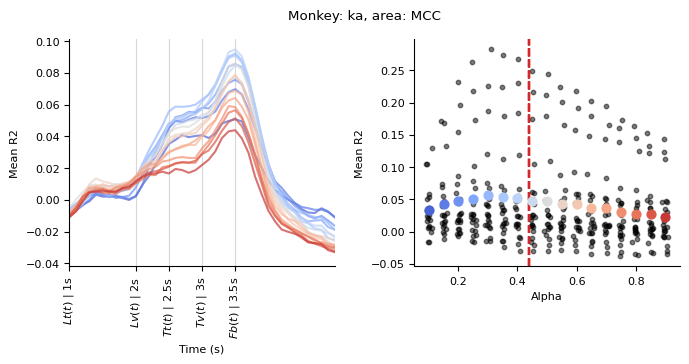

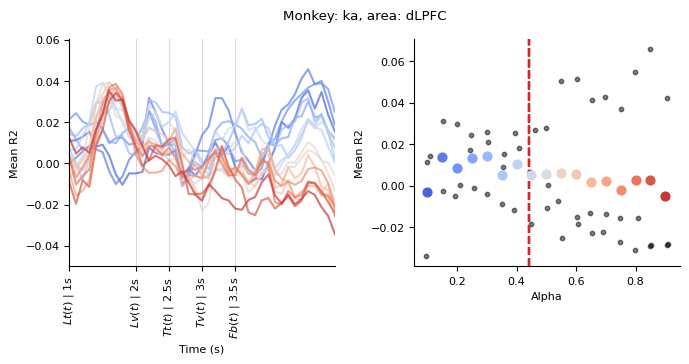

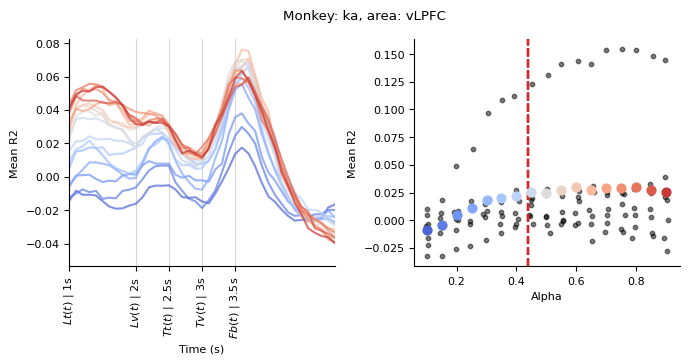

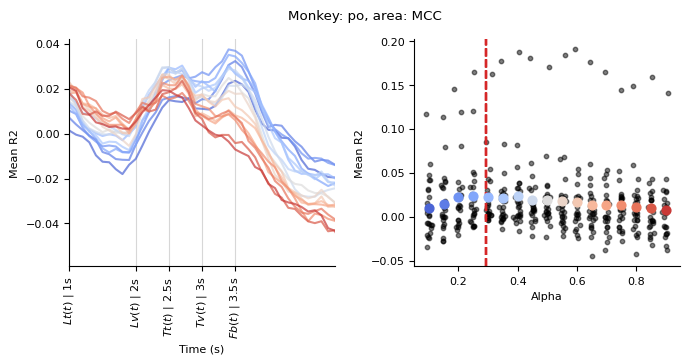

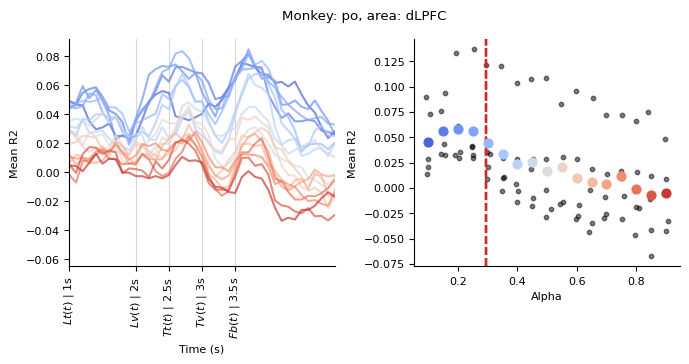

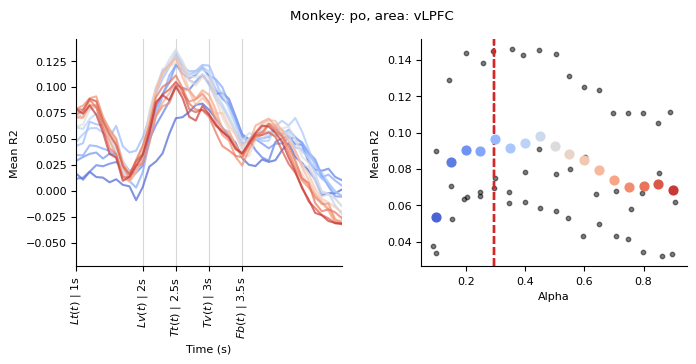

In [6]:
cut_percentile = .1  # we remove extreme outliers to get interpretable results
eval_window = [2, 3.5]  # this is the time window under which we average the decoder performances for the second plot

x_lim=(1, 5)  # time window to show

paper_format = False
show_datapoints = True  # whether to show individual data points or not

monkeys = np.unique(res_alphas_original.monkey.values)
areas = ['MCC', 'dLPFC', 'vLPFC']
targets = res_alphas_original.target.values
alphas = [float(target.split("_")[-1]) for target in targets]

# color gradient red to green
colors = plt.cm.coolwarm(np.linspace(0, 1, len(targets)))
from popy.config import MODEL_PARAMS
alpha_monkey = {'ka': MODEL_PARAMS['ka']['alpha'], 'po': MODEL_PARAMS['po']['alpha']}

# plot size in cm
if paper_format:
    w = 6
    h = 4
else:
    w = 20
    h = 15
    
best_scores = []
for m, monkey_temp in enumerate(monkeys):
    for a, area_temp in enumerate(areas):
        
        fig, axs = plt.subplots(1, 2, figsize=(w/2.54, (h/2)/2.54))

        # set padding to 0
        plt.subplots_adjust(wspace=0.3, hspace=0)
        title = f'Monkey: {monkey_temp}, area: {area_temp}'
        fig.suptitle(title)
        
        for i, target_temp in enumerate(targets):
            if i == 0 or i == len(targets)-1:
                continue
            
            # get scores for this target (a given alpha), monkey and area
            res_alphas_temp = res_alphas_original.sel(target=target_temp, session=res_alphas_original.monkey == monkey_temp)
            scores_temp = res_alphas_temp.scores

            # remove outliers
            scores_temp = scores_temp.where(scores_temp > scores_temp.quantile(cut_percentile), np.nan)  
            
            # take a mean measurement (1) across sessions AND (2) across session and time within the eval window
            if area_temp == 'MCC':
                scores_in_time = scores_temp.sel(area=area_temp).mean('session')
                scores_at_time = scores_temp.sel(area=area_temp, time=slice(*eval_window)).mean('time')
            else:
                scores_in_time = scores_temp.sel(area='LPFC', session=scores_temp.lpfc_subregion == area_temp).mean('session')
                scores_at_time = scores_temp.sel(area='LPFC', session=scores_temp.lpfc_subregion == area_temp, time=slice(*eval_window)).mean('time')

            ### plotting

            # plot every 4th trajectorie for clarity
            #if (i-1) % 4 == 0:                
            # plot mean r2 over time
            ax = axs[0]
            scores_in_time_smooth = np.convolve(scores_in_time, np.ones(5)/5, mode='same')
            ax.plot(res_alphas_temp.time, scores_in_time_smooth, color=colors[i], linewidth=1.5, alpha=.7)

            # plot mean r2 at time
            ax = axs[1]  
            '''sns.boxplot(
                x=alphas[i],
                y=scores_at_time,
                color=colors[i],
                ax=ax,
                showfliers=False  # show outliers (default is True, but set explicitly)
            )'''

            # Plot individual data points with actual x-values

            ax.scatter(
                alphas[i],
                scores_at_time.mean(),
                color=colors[i],
                s=40,  # size
                alpha=1,
                zorder=10
            )

            # Add jitter to x-coordinates for better visualization
            if show_datapoints:
                x_jittered = alphas[i] + np.random.normal(0, 0.005, len(scores_at_time))
                
                ax.scatter(
                    x_jittered,
                    scores_at_time,
                    color='black',
                    s=10,  # size
                    alpha=0.5
                )

            ax.axvline(alpha_monkey[monkey_temp], color='tab:red', linestyle='--', alpha=.5)

            # get best score for this alpha, monkey and area
            best_scores.append({'monkey': monkey_temp, 'area': area_temp, 'alpha':alphas[i], 'best_scores': scores_at_time})

        # set plot properties
        for i in range(2):
            plot_keypoints(axs[0], n_extra_trials=(0, 0), fontsize=8, rotation=90)
            axs[0].grid(axis='x', alpha=.5)
            axs[0].set_xlim(x_lim)
            # reset ylim
            ylim = axs[0].get_ylim()
            axs[0].set_ylim(ylim)
            #axs[i, 1].legend()
            axs[1].set_xlabel('Alpha')
            axs[0].set_xlabel('Time (s)')

            for j in range(2):
                if i == 0:
                    axs[j].set_ylabel('% signif sessions')
                else:
                    axs[j].set_ylabel('Mean R2')

                axs[j].spines['top'].set_visible(False)
                axs[j].spines['right'].set_visible(False)

        #plt.tight_layout()

        #floc = os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', f'multiple_alphas_{monkey_temp}_{area_temp}.svg')
        #fig.savefig(floc, bbox_inches='tight', dpi=300, transparent=True)

In [7]:
res_alphas_original

<xarray.Dataset>
Dimensions:         (target: 19, session: 115, time: 75, area: 2)
Coordinates:
  * target          (target) <U15 'stay_value_0.05' ... 'stay_value_0.95'
  * area            (area) object 'LPFC' 'MCC'
  * time            (time) float64 0.0 0.1 0.2 0.3 0.4 ... 7.0 7.1 7.2 7.3 7.4
  * session         (session) object 'ka_230520' 'ka_090720' ... 'po_200722'
    monkey          (session) object 'ka' 'ka' 'ka' 'ka' ... 'po' 'po' 'po' 'po'
    lpfc_subregion  (session) <U5 'dLPFC' 'dLPFC' 'dLPFC' ... 'dLPFC' 'dLPFC'
    x               (session, area) float64 -1.0 3.0 -4.0 nan ... -3.0 -5.0 -1.0
    y               (session, area) float64 -1.0 3.0 -2.0 nan ... 4.0 -2.0 6.0
Data variables:
    scores          (target, session, time, area) float64 nan nan ... -0.05522
    pvals           (target, session, time, area) float64 nan nan ... nan 0.1238
    perm_mean       (target, session, time, area) float64 nan nan ... -0.09404
    perm_std        (target, session, time, area) float64 nan nan ... 0.03253
    if_significant  (target, session, time, area) bool True True ... True False

In [8]:
cut_percentile = .1  # we remove extreme outliers to get interpretable results
eval_window = [2, 3.5]  # this is the time window under which we average the decoder performances for the second plot

alphas = [float(target.split("_")[-1]) for target in targets]

res_grid = []
# if all none, skip it:
not_skipped_count = 0

for m, sess_temp in enumerate(res_alphas_original.session.values):
    data_temp = res_alphas_original.sel(session=sess_temp, area='MCC')

    if np.all(np.isnan(data_temp.scores)):
        continue
    not_skipped_count += 1
    
    best_alpha = None
    best_score = -np.inf
    for target_temp in data_temp.target.values:
        res_alphas_temp = data_temp.sel(target=target_temp)

        # get scores for this target (a given alpha), monkey and area
        scores_temp = res_alphas_temp.scores

        # if all nan:  continue
        if np.all(np.isnan(scores_temp)):
            continue

        # remove outliers
        scores_temp = scores_temp.where(scores_temp > scores_temp.quantile(cut_percentile), np.nan)  

        # take a mean measurement (1) across sessions AND (2) across session and time within the eval window
        scores_at_time = scores_temp.sel(time=slice(*eval_window)).mean('time')

        if scores_at_time > best_score:
            best_score = scores_at_time
            best_alpha = target_temp

    # add the result to the res_grid list
    res_grid.append({
        'monkey': str(res_alphas_temp.monkey.values),
        'session': str(res_alphas_temp.session.values),
        'area': str(res_alphas_temp.area.values),
        'x': int(res_alphas_temp.x.values), 
        'y': int(res_alphas_temp.y.values), 
        'best_alpha': float(best_alpha.split('_')[-1]),
        'best_score': float(best_score.data),
    })

res_grid = pd.DataFrame(res_grid)
print(f'finished processing, not skipped count: {not_skipped_count}/{len(res_alphas_original.session.values)}')

finished processing, not skipped count: 47/115


## Plot best alpha per monkey on x-y coordinate system

In [46]:
res_temp

,monkey,session,area,x,y,best_alpha,best_score
0,ka,050620,MCC,0,5,0.30,0.120360
1,ka,150720,MCC,2,4,0.70,0.032941
2,ka,010720,MCC,1,7,0.50,0.054843
3,ka,270720,MCC,-1,4,0.30,0.018156
4,ka,170920,MCC,1,4,0.90,0.035797
5,ka,120820,MCC,-5,5,0.10,0.033556
6,ka,041220,MCC,-1,3,0.05,0.069066
7,ka,150221,MCC,1,5,0.15,0.055443
8,ka,040321,MCC,-2,6,0.40,0.230191
9,ka,190821,MCC,5,4,0.70,0.008915


In [17]:
from popy.plotting.plot_cortical_grid import _get_grid_location, _init_location_grid

def _plot_matrix_best_LR(grid: xr.DataArray,
                monkey: str,
                ax=None, fig=None, title=None, label=None, vmin=None, vmax=None, print_values=False, cmap=plt.cm.get_cmap('Greys')):
    """
    Helper function for plot_on_cortical_grid().

    A plotting method to plot a heatmap grid on the cortical grid of Clement. 
    It loads an image of the sulci of the monkey, and plots the matrix on top of it.

    Parameters
    ----------

    grid : xr.DataArray
        A 19x19 grid with coordinates of the cortical grid of Clement, created by the function init_location_grid.

    monkey : str
        The monkey name, to load the sulci image.

    etc...
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(70, 70))
        show = False

    # ploting helpers
    vmin = np.nanmin(grid) if vmin is None else vmin
    vmax = np.nanmax(grid) if vmax is None else vmax
    # Create blue to yellow colormap
    custom_cmap = plt.cm.get_cmap('viridis')
    norm = mcolors.Normalize(vmin=0, vmax=1)
    
    # Plot data as scatter
    for x in grid.coords['x']:
        for y in grid.coords['y']:
            value = grid.sel(x=x, y=y).values
            if not np.isnan(value):
                color = custom_cmap(norm(value))
                ax.scatter(x, y, s=20, c=[value], cmap=custom_cmap, vmin=0, vmax=1, alpha=0.8,
                            zorder=5, edgecolors='black', linewidth=0.5)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label=label if label is not None else '', shrink=0.3)
    # bartitle: Best-fitting LR
    cbar.set_label(label if label is not None else 'Best-fitting LR', rotation=270, labelpad=15)

    if print_values:
        # plot values on the grid
        for x in grid.coords['x']:
            for y in grid.coords['y']:
                value = grid.sel(x=x, y=y).values
                if not np.isnan(value):
                    ax.text(x-.2, y+.2, str(int(value)), ha="center", va="center", color="black", fontsize=5, zorder=5, alpha=.5)
                
  
    # plot grey square where its no recording
    #ax.imshow(non_significants, cmap='Greys', alpha=.5, aspect='auto', origin='upper', extent=[-9, 9, -9, 9], vmin=-.1, vmax=.1)

    # plot sulci
    floc = os.path.join(cfg.PROJECT_PATH_LOCAL, 'data', 'recording_sites', f'sulci_{monkey}.png')  # load sulcus png
    img = plt.imread(floc)
    img = np.rot90(img, k=3)  # rotate the image 90 degrees counter-clockwise
    ax.imshow(img, origin='lower', extent=[-10, 10, -10, 10], zorder=10)  # plot sulci, bring to front
    

    # put text on top of the grid (LPFC MCC)
    pos_1 = [2, 8]
    pos_2 = [-4, -8.5]
    ax.text(pos_1[0], pos_1[1], 'MCC', ha="center", va="center", color="black", fontsize=10)
    ax.text(pos_2[0], pos_2[1], 'LPFC', ha="center", va="center", color="black", fontsize=10)

    # text on 'lateral, medial, anterior, posterior'
    ax.set_xlabel('Cortical position (mm)')
    ax.set_ylabel('Cortical position (mm)')
    ax.text(-8, -12, 'ant.', ha="center", va="center", color="black")
    ax.text(8, -12, 'post.', ha="center", va="center", color="black")
    ax.text(-12.5, 8, 'med.', ha="center", va="center", color="black", rotation=90)
    ax.text(-12.5, -8, 'lat.', ha="center", va="center", color="black", rotation=90)

    # show minor ticks at every 1, major at every 2
    ax.set_xticks(np.arange(-8, 9, 1), minor=True)
    ax.set_yticks(np.arange(-8, 9, 1), minor=True)
    ax.set_xticks(np.arange(-8, 9, 2), minor=False)
    ax.set_yticks(np.arange(-8, 9, 2), minor=False)
    #ax.grid(True, which='both', axis='both', linestyle='-', linewidth=1, color='grey', alpha=0.2)

    ax.set(xlim=(-9.5, 9.5), ylim=(-9.5, 9.5), aspect='equal')    
    sns.despine()

    # set title
    if title is not None:
        ax.set_title(title)

    return fig, ax


def plot_on_cortical_grid_best_LR(
        df: pd.DataFrame,
        column_to_show=None,
        vmin=None, 
        vmax=None, 
        title=None, 
        bar_title=None,
        ax=None,
        print_values=False
        ):
    """
    The full routine to plot the data on the cortical grid of Clement. It will plot the data for each monkey, and each area, on the grid.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe containing the data. The dataframe should contain the columns 'monkey', 'session', 'area', and the column to show.

    column_to_show : str
        The column to show on the grid. This is the column that will be plotted on the grid.

    vmin : float
        The minimum value of the colorbar. If None, it will be the minimum value of the data.

    vmax : float
        The maximum value of the colorbar. If None, it will be the maximum value of the data.

    title : str
        The title of the plot.

    bar_title : str
        The title of the colorbar.
    """

    # get the data for the current monkey
    if ax is None:
        cm_to_in = 1/2.54
        fig, ax = plt.subplots(1, 1, figsize=(8*cm_to_in, 12*cm_to_in))
        newfig = True

    # init grid 
    grid = _init_location_grid()
    
    # get the data for the current monkey, set it to the grid value
    locs_already_used = set()
    for (monkey, session, area), sub_df in df.groupby(['monkey', 'session', 'area']):
        # get the location of the current session, area for this monkey
        grid_loc_temp = _get_grid_location(monkey, session, area)
        if np.isnan(grid_loc_temp).any():
            continue

        # add to the grid (if the location is not already used, esle use the better value)
        value_to_show = sub_df[column_to_show].values[0]
        if grid_loc_temp not in locs_already_used:
            grid.loc[dict(x=grid_loc_temp[0], y=grid_loc_temp[1])] = value_to_show
            locs_already_used.add(grid_loc_temp)
        else:  # use the higher value
            grid.loc[dict(x=grid_loc_temp[0], y=grid_loc_temp[1])] = np.sum((value_to_show, grid.loc[dict(x=grid_loc_temp[0], y=grid_loc_temp[1])]))

    # plot the grid on the subplot
    _plot_matrix_best_LR(grid, monkey, ax=ax, title=f"Monkey {monkey.upper()}", label=bar_title, vmin=vmin, vmax=vmax, print_values=print_values)

    if title is not None:
        ax.set_title(title)

    plt.tight_layout()

    if newfig:
        return fig, ax
    else:
        return ax



/tmp/ipykernel_1217844/459808257.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax=None, fig=None, title=None, label=None, vmin=None, vmax=None, print_values=False, cmap=plt.cm.get_cmap('Greys')):


/tmp/ipykernel_1217844/459808257.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_cmap = plt.cm.get_cmap('viridis')


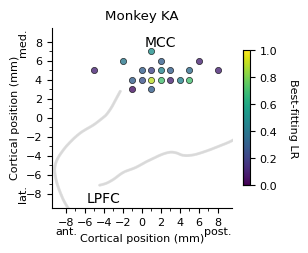

/tmp/ipykernel_1217844/459808257.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_cmap = plt.cm.get_cmap('viridis')


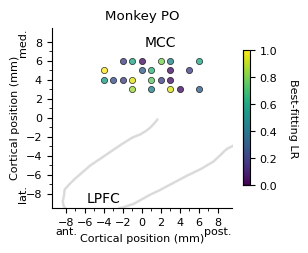

In [18]:
monkeys = res_grid['monkey'].unique()

for monkey in monkeys:
    res_temp = res_grid[res_grid['monkey'] == monkey].copy()

    # remove **_ from session name (keep whats left behind the underscore)
    res_temp['session'] = res_temp['session'].str.split('_').str[1].astype(str)
    fig, ax = plot_on_cortical_grid_best_LR(res_temp, 'best_alpha')
    # save as svg, dpi 300
    fig.savefig(f"../figs/cortical_grid_{monkey}_best_alpha.svg", dpi=300, bbox_inches='tight')
    plt.show()

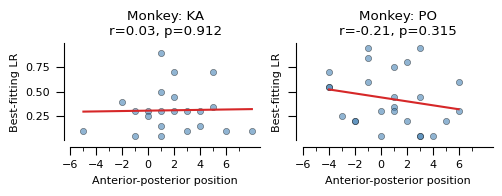

In [26]:
# X coordinate vs best alpha, with linear fit per monkey
from scipy.stats import linregress
# fontsize 8
plt.rcParams.update({'font.size': 8})

fig2, axes2 = plt.subplots(1, 2, figsize=(5, 2), sharey=True, sharex=True)

for i, monkey in enumerate(monkeys):
    monkey_data = res_grid[res_grid['monkey'] == monkey].copy()
    monkey_data['best_alpha_float'] = monkey_data['best_alpha'].astype(float)

    x = monkey_data['x'].to_numpy(dtype=float)
    y = monkey_data['best_alpha_float'].to_numpy()

    axes2[i].scatter(x, y, s=20, alpha=0.6, edgecolors='black', linewidths=0.4, color='steelblue')

    # Linear fit
    slope, intercept, r, pval, _ = linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    axes2[i].plot(x_line, slope * x_line + intercept, color='tab:red', linewidth=1.5)
    p_str = "p<0.001" if pval < 0.001 else f"p={pval:.3f}"
    axes2[i].set_title(f'Monkey: {monkey.upper()}\nr={r:.2f}, {p_str}')

    axes2[i].set_xlabel('Anterior-posterior position')
    axes2[i].set_ylabel('Best-fitting LR')
    #axes2[i].grid(True, alpha=0.3)
    import seaborn as sns
    sns.despine(ax=axes2[i])
    axes2[i].spines['left'].set_position(('outward', 5))
    axes2[i].spines['bottom'].set_position(('outward', 5))
    
    # Set x-axis ticks: major ticks at even values (-8, -6, -4, -2, 0, 2, 4, 6, 8)
    # and minor ticks at odd values (-7, -5, -3, -1, 1, 3, 5, 7)
    major_ticks = np.arange(-6, 7, 2)
    minor_ticks = np.arange(-5, 8, 2)
    
    axes2[i].set_xticks(major_ticks)
    axes2[i].set_xticks(minor_ticks, minor=True)
    axes2[i].tick_params(which='major', length=6)
    axes2[i].tick_params(which='minor', length=3, labelbottom=False)

plt.tight_layout()
# save as svg, dpi 300
fig2.savefig(f"../figs/best_alpha_vs_x_position.svg", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.gridspec as gridspec

cut_percentile = 0.01  # we remove extreme outliers to get interpretable results
eval_window = [2, 3.5]  # this is the time window under which we average the decoder performances for the second plot

x_lim=(1, 4)  # time window to show

paper_format = True
show_datapoints = False  # whether to show individual data points or not

monkeys = np.unique(res_alphas_original.monkey.values)
areas = ['MCC', 'dLPFC', 'vLPFC']
targets = res_alphas_original.target.values
alphas = [float(target.split("_")[-1]) for target in targets]

# color gradient red to green
colors = plt.cm.coolwarm(np.linspace(0, 1, len(targets)))
from popy.config import MODEL_PARAMS
alpha_monkey = {'ka': MODEL_PARAMS['ka']['alpha'], 'po': MODEL_PARAMS['po']['alpha']}

# plot size in cm
if paper_format:
    w = 30
    h = 9
    s = 15
    lw = 1
else:
    w = 36
    h = 18
    s = 40
    lw = 1.5

# Create figure
fig = plt.figure(figsize=(w/2.54, h/2.54))

# Create a master grid: 2 rows (monkeys) × 3 columns (areas)
outer_grid = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.3)

# Iterate through each monkey-area combination
for m, monkey_temp in enumerate(monkeys):
    for a, area_temp in enumerate(areas):
        
        # Create inner grid for this (monkey, area) pair: 1 row × 2 columns with NO gap
        inner_grid = gridspec.GridSpecFromSubplotSpec(1, 2, outer_grid[m, a], 
                                                     wspace=0.2, hspace=0)
        
        # Create subplots - time series first, then alpha with shared y-axis
        ax_time = fig.add_subplot(inner_grid[0, 0])   # Time series subplot
        ax_alpha = fig.add_subplot(inner_grid[0, 1], sharey=ax_time)  # Alpha subplot with shared y

        for i, target_temp in enumerate(targets):
            if i == 0 or i == len(targets)-1:
                continue
            
            res_alphas_temp = res_alphas_original.sel(target=target_temp, session=res_alphas_original.monkey == monkey_temp)

            scores_temp = res_alphas_temp.scores
            scores_temp = scores_temp.where(scores_temp > scores_temp.quantile(cut_percentile), np.nan)  # remove outliers
            
            if area_temp == 'MCC':
                scores_all = scores_temp.sel(area=area_temp)
                scores_in_time = scores_all.mean('session')
                scores_at_time = scores_all.sel(time=slice(*eval_window)).mean('time')      
            else:
                scores_all = scores_temp.sel(area='LPFC', session=scores_temp.lpfc_subregion == area_temp)
                scores_in_time = scores_all.mean('session')
                scores_at_time = scores_all.sel(time=slice(*eval_window)).mean('time')

            # Plot time series
            scores_in_time_smooth = np.convolve(scores_in_time, np.ones(5)/5, mode='same')
            ax_time.plot(res_alphas_temp.time, scores_in_time_smooth, color=colors[i], alpha=.7, linewidth=lw)

            # Plot alpha scatter
            ax_alpha.scatter(
                alphas[i],
                scores_at_time.mean(),
                color=colors[i],
                s=s,
                alpha=1,
                zorder=10
            )

            # Add individual data points with jitter
            if show_datapoints:
                x_jittered = alphas[i] + np.random.normal(0, 0.005, len(scores_at_time))
                ax_alpha.scatter(
                    x_jittered,
                    scores_at_time,
                    color='black',
                    s=s/5,
                    alpha=0.5
                )

        # add grey shadow in the background for the time of interest
        ax_time.axvspan(eval_window[0], eval_window[1], color='grey', alpha=0.1, label='Eval Window')

        n_sessions = len(scores_all)
        n_sessions_nonnan = np.count_nonzero(~np.isnan((scores_all.mean('time'))))
        n_sessions_nan = np.count_nonzero(np.isnan((scores_all.mean('time'))))
        print(f'{monkey_temp} - {area_temp}: {n_sessions_nonnan} / {n_sessions} sessions ({n_sessions_nan} NaN)')
         
        # Set titles only on top row
        ax_time.set_title(f'{monkey_temp} {area_temp}', fontsize=10)
        ax_alpha.set_title(f'{monkey_temp} {area_temp} - t={eval_window}, n={n_sessions_nonnan}', fontsize=10)

        # Add vertical line for monkey-specific alpha
        ax_alpha.axvline(alpha_monkey[monkey_temp], color='tab:red', linestyle='--', alpha=.5)

        # Set properties for time series plot
        plot_keypoints(ax_time, n_extra_trials=(0, 0), fontsize=8, rotation=45)
        ax_time.grid(axis='x', alpha=.5)
        ax_time.set_xlim(x_lim)
        
        # Manually adjust y-axis limits based on visible data within x_lim
        y_values = []
        for line in ax_time.get_lines():
            x_data = line.get_xdata()
            y_data = line.get_ydata()
            # Find y values within the x_lim range
            mask = (x_data >= x_lim[0]) & (x_data <= x_lim[1])
            if np.any(mask):
                y_values.extend(y_data[mask])
        
        if y_values:
            y_min, y_max = np.nanmin(y_values), np.nanmax(y_values)
            y_range = y_max - y_min
            margin = y_range * 0.05  # Add 5% margin
            ax_time.set_ylim(y_min - margin, y_max + margin)
        
        # Set x-labels only on bottom row
        if m == len(monkeys) - 1:
            ax_time.set_xlabel('Time (s)')
            ax_alpha.set_xlabel('Alpha')
        
        # Set y-labels only on leftmost subplots
        if a == 0:
            ax_time.set_ylabel('Mean R2')
        else:
            # Remove y-axis labels and ticks for non-leftmost time plots
            #ax_time.set_ylabel('')
            #ax_time.tick_params(left=False, labelleft=False)
            ...
        
        # Remove spines
        ax_time.spines['top'].set_visible(False)
        ax_time.spines['right'].set_visible(False)
        ax_alpha.spines['top'].set_visible(False)
        ax_alpha.spines['right'].set_visible(False)
        
        # Remove left spine and ticks of alpha plot for seamless connection
        #ax_alpha.spines['left'].set_visible(False)
        #ax_alpha.tick_params(left=False, labelleft=False)

        ax_alpha.axhline(0, color='black', linewidth=.5)
        ax_time.axhline(0, color='black', linewidth=.5)

if paper_format:
    plt.tight_layout()

# Uncomment to save
floc = os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'combined_grid_plot.svg')
fig.savefig(floc, bbox_inches='tight', dpi=300, transparent=True)

plt.show()

---
# 3. Decoding feedback

## Current outcome

In [ ]:
folder='fb_target'

res = load_decoding_res_new(folder=folder)
res

In [ ]:
plot_analysis('feedback', 
              plim=.05, 
              vmin=0.4, vmax=.9, 
              n_extra_trials=(0, 1), 
              N_consecutives=2,
              x_lim=(3, 7),
              prop_lim=[0, 105],
              bar_title='Decoding accuracy (R2)',
              folder='fb_target')

---
## Historical outcomes

In [ ]:
def add_if_signif(res, plim=.05, N_consecutives=4):
    res_teagrets = []
    for j, target in enumerate(res.target.values):
        # mask significants, convert to 0 or 1 instead of p values
        res_temp = res.sel(target=target)
        res_temp_signifs = mask_N_consecutives(res_temp.pvals <= plim, N=N_consecutives)  # mask N consecutive non-significant bins
        res_temp['if_significant'] = res_temp_signifs  # add as new dataarray to the results

        res_teagrets.append(res_temp)

    res = xr.concat(res_teagrets, dim='target')
    return res  

def remove_irrelevant_sessions(res):
    signif_value_sessions = pd.read_csv('signif_value_sessions.csv')

    sessions_good = []
    for session in res.session.data:
        for area in res.area.data:
            if signif_value_sessions.loc[(signif_value_sessions['session'] == session) & (signif_value_sessions['area'] == area), 'if_significant'].values[0]:  # if there is any significant time point in the 2-3.5 window, we keep the session and area
                sessions_good.append((session, area))
            else:
                res.loc[dict(session=session, area=area)] = np.nan
                
            '''res_temp = res.sel(session=session, area=area)

            if res_temp.if_significant.sel(time=slice(2, 3.5)).sum() >= 1:  # if there is any significant time point in the 2-3.5 window, we keep the session and area
                sessions_good.append((session, area))
            else:
                res.loc[dict(session=session, area=area)] = np.nan'''
                
    print(f'kept: {len(sessions_good)} / {len(res.session.data)*len(res.area.data)}')
    return res

In [ ]:
folder='history'

res = load_decoding_res_new(folder=folder)
res = add_if_signif(res, plim=.05, N_consecutives=3)
res = remove_irrelevant_sessions(res)
res = add_subareas(res)  # add subareas to the results 
# if 'group' in dims and its nan, remove it. if not nan, raise error


res

In [ ]:
def init_axs(): 

    # Create figure with 2 main columns per row (ratio 2:1), then subdivide first column into 4
    fig = plt.figure(figsize=(w, h))
    
    # Main grid: 3 rows, 2 columns with 2:1 ratio
    main_gs = fig.add_gridspec(3, 2, width_ratios=[2, .8], wspace=0.2, hspace=0.3)
    
    axs = []
    for i in range(3):  # 3 rows
        row_axes = []
        
        # Subdivide the first main column into 4 subcolumns
        sub_gs = main_gs[i, 0].subgridspec(1, 4, wspace=0.2)
        
        # Create the 4 subplots in the subdivided area
        for j in range(4):
            if j == 0:
                # First subplot - no sharing initially
                ax = fig.add_subplot(sub_gs[0, j])
                first_ax = ax  # Keep reference for sharing
            else:
                # Share y-axis with first subplot in the row
                ax = fig.add_subplot(sub_gs[0, j], sharey=first_ax)
                
            # Share x-axis with corresponding subplot in first row
            if i > 0:
                ax.sharex(axs[0][j])
                
            row_axes.append(ax)
        
        # Create the 5th subplot (right main column)
        ax5 = fig.add_subplot(main_gs[i, 1])
        if i > 0:
            ax5.sharex(axs[0][4])  # Share x-axis with first row's 5th subplot
        row_axes.append(ax5)
        
        axs.append(row_axes)

    return fig, axs

In [ ]:
from scipy import ndimage
from scipy.optimize import curve_fit
from scipy import stats

#target='R_1'
vmin=0.4
vmax=.8
n_extra_trials=(0, 1)
x_lim=(1, 5)
prop_lim=[0, 100]
bar_title='Decoding accuracy (R2)'
folder='history'
t_window = [1, 3.5]  # time window of interest for the decoding accuracy

add_stir = False

mode = 'mean_performance'  # 'mean_performance' or 'prop_signifs'

paper_format=True
if paper_format:
    w = 7
    h = 1.4 * 3
    plt.rcParams.update({'font.size': 8})


subregions = ['MCC', 'dLPFC', 'vLPFC']

for m, monkey in enumerate(np.unique(res.monkey.values)):
    # Create subplots
    fig, axs = init_axs()

    hist_weights = {subregion: [] for subregion in subregions}
    df_list = []

    for j, target in enumerate(res.target.values):
        for i, subregion in enumerate(subregions):
            # get subregion intead of region
            res_temp_target_monkey = res.sel(target=target, session=res.monkey == monkey)
            if subregion == 'MCC':
                res_temp = res_temp_target_monkey.sel(area='MCC')
            else:
                res_temp = res_temp_target_monkey.sel(area='LPFC', session=res_temp_target_monkey.lpfc_subregion == subregion)

            # extract data to plot
            if mode == 'prop_signifs':
                # plot num significant over time
                data = res_temp.if_significant
                data_in_time = res_temp.if_significant.mean('session') * 100
                data_at_time = res_temp.if_significant.mean('session').sel(time=slice(t_window[0], t_window[1])).mean().item() * 100

            elif mode == 'mean_performance':
                data = res_temp.scores
                if not np.all(np.isnan(data)):  # is not all nans, take a mean, else skip this target in this subregion
                    data_in_time = res_temp.scores.mean(dim='session')
                    sessions_at_time = res_temp.scores.sel(time=slice(t_window[0], t_window[1])).mean('time')
                    data_at_time = sessions_at_time.mean(dim='session').item()

                    data_se_in_time = res_temp.scores.std(dim='session') / np.sqrt(len(res_temp.session))
                    data_se_at_time = res_temp.scores.sel(time=slice(t_window[0], t_window[1])).std(dim='session') / np.sqrt(len(res_temp.session))
                else:
                    continue

            # Plotting 4 first plots
            if j <= 3:
                ax = axs[i][j]

                data_in_time = ndimage.convolve(data_in_time, np.ones(5)/5, mode='nearest')
                ax.plot(res_temp.time, data_in_time, color=COLORS[subregion])

                if mode == 'mean_performance':
                    data_se_in_time = ndimage.convolve(data_se_in_time, np.ones(5)/5, mode='nearest')
                    ax.fill_between(res_temp.time, data_in_time - data_se_in_time, data_in_time + data_se_in_time, color='black', alpha=0.1)

            # plotting last column
            ax = axs[i][-1]

            #scores_mean_temp = res_temp.scores.sel(time=slice(t_window[0], t_window[1])).mean('time').mean(dim='session')
            #scores_se_temp = res_temp.scores.sel(time=slice(t_window[0], t_window[1])).mean('time').std(dim='session') / np.sqrt(len(res_temp.session))
            ax.scatter(j, data_at_time, label=f"Fb t-{target.split('_')[-1]}", s=40, color=COLORS[subregion], zorder=10, edgecolors='black')
            #ax.errorbar(j, scores_mean_temp, yerr=scores_se_temp, fmt='o', color=COLORS[subregion])

            hist_weights[subregion].append(data_at_time)

            # Create a DataFrame for seaborn
            for session_idx, session in enumerate(sessions_at_time.session):
                df_list.append({
                    'session': session,
                    'subregion': subregion,
                    'score': float(sessions_at_time.sel(session=session).data),
                    'any_signif': res_temp.if_significant.mean('session').sel(time=slice(t_window[0], t_window[1])).sum().item()>=1,
                    'condition': f"Fb t-{target.split('_')[-1]}",  # or whatever grouping you want
                    'x_pos': j  # your x-position
                })

    df_temp = pd.DataFrame(df_list)

    # Create the plot with both boxplot and individual points
    # Option 1: Using stripplot (random jitter)
    '''sns.boxplot(data=df_temp, x='x_pos', y='score',
            color=COLORS[subregion],
            showfliers=False,
            boxprops={'linewidth': 0.5},
            ax=ax)'''
    
    for i, subregion in enumerate(subregions):
        ax = axs[i][-1]

        if add_stir:
            sns.stripplot(data=df_temp.loc[df_temp['subregion']==subregion],
                            x='x_pos', y='score',
                            color=COLORS[subregion],
                            size=3,
                            alpha=.4,
                            jitter=0.2,
                            legend=False,
                            ax=ax)  # Amount of horizontal jitter
    
        # compare each x_pos to x_pos==7 - is it significantly different? mark it by star
        # Statistical significance testing and annotation
        subregion_data = df_temp.loc[df_temp['subregion']==subregion].dropna()
        reference_group = subregion_data[subregion_data['x_pos'] == 7]['score']

        # Get unique x_pos values (excluding the reference group)
        x_positions = sorted(subregion_data['x_pos'].unique())
        x_positions = [x for x in x_positions if x != 7]

        # Perform statistical tests and add stars
        for x_pos in x_positions:
            test_group = subregion_data[subregion_data['x_pos'] == x_pos]['score']
            
            # Perform t-test (you can also use Mann-Whitney U test with stats.mannwhitneyu)
            statistic, p_value = stats.ttest_ind(test_group, reference_group)

            #p_value = 0.01 if np.any(subregion_data.loc[(subregion_data['x_pos'] == x_pos) & (subregion_data['any_signif'])]) else 0.1

            # Determine significance level and star annotation
            if p_value < 0.001:
                stars = '***'
            elif p_value < 0.01:
                stars = '**'
            elif p_value < 0.05:
                stars = '*'
            else:
                stars = ''  # Not significant
            
            # Add star annotation if significant
            if stars:
                # Get the maximum y-value for this x_pos to place the star above
                mean_y = test_group.mean()
                y_offset = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02  # 2% of y-range
                
                ax.text(x_pos, mean_y + y_offset, stars, 
                        ha='center', va='bottom', 
                        fontsize=12, fontweight='bold')


        ### fit exponential of form alpha * (1-alpha)**x
        ax = axs[i][-1]
        
        hist_weights_temp = np.array(hist_weights[subregion])
        x = np.arange(len(hist_weights_temp))
        y = hist_weights_temp
        popt, pcov = curve_fit(lambda x, c, a, b: c * (a * (1 - a) ** x) + b, x, y)
        print(f'{monkey}: c={popt[0]:.2f}, a={popt[1]:.2f}, b={popt[2]:.2f}')

        x_continuous = np.arange(0, len(hist_weights_temp), 0.01)
        ax.plot(x_continuous, popt[0] * (popt[1] * (1 - popt[1]) ** x_continuous) + popt[2], color='black', linestyle='-', label='Exponential fit', linewidth=1)
        ax.text(0.25, 0.95, f'alpha = {popt[1]:.2f}', transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
        

    ### Plotting settings
    plt.suptitle(f'Monkey {monkey}')

    for j, target in enumerate(res.target.values):
        for i, subregion in enumerate(subregions):

            if j <= 3:
                ax = axs[i][j]
                
                ax.axvline(3.5, color='black', linewidth=1, label='Feedback onset')
                ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
                plot_keypoints(ax, n_extra_trials=n_extra_trials, fontsize=8)

                ax.grid(axis='x', alpha=.5)

                #ax.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
                ax.set_xlim(x_lim)
                ax.set_ylim(ax.get_ylim())

                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)

                if j == 0:
                    if mode == 'prop_signifs':
                        ax.set_ylabel('Percent of\ndignif. sessions (%)')
                    elif mode == 'mean_performance':
                        ax.set_ylabel('Mean\naccuracy (%)')
                else:
                    ax.spines['left'].set_visible(False)
                    # Hide y-tick labels for shared y-axis subplots (except the first one)
                    ax.tick_params(labelleft=False)

                if i == 0:
                    ax.set_title(f'Decoder fit on\ntrial t-{target.split("_")[-1]}')
                if i == 2:
                    ax.set_xlabel('Time (s)')
                else:
                    ax.set_xlabel('')
                    # Hide x-tick labels for non-bottom rows
                    ax.tick_params(labelbottom=False)

            ax = axs[i][-1]

            ax.axhline(0.5, color='black', linestyle='--', linewidth=.7)
            ax.set_ylim([0.495, ax.get_ylim()[1]*1.001])
            ax.set_xticks(np.arange(len(res.target.values)))
            ax.set_xticklabels([f't-{target.split("_")[-1]}' for target in res.target.values])

            #ax.set_ylabel('Decoding accuracy (R2) at 3.5s')
            if i == 0:
                if mode == 'prop_signifs':
                    ax.set_title('Mean percent of\ndsignif. sessions (%)')
                elif mode == 'mean_performance':
                    ax.set_title(f'mean accs in window\n{t_window[0]}s - {t_window[1]}s')
            if i == 2:
                ax.set_xlabel('Trials into past')
            else:
                ax.set_xlabel('')
                ax.tick_params(labelbottom=False)
            #ax.legend(title='Trials into past', bbox_to_anchor=(1.05, 1), loc='upper left')

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    #plt.tight_layout()
    #plt.show()

    # save as svg
    fig.savefig(f'figs/history_decoding_{monkey}.svg', bbox_inches='tight', transparent=True, dpi=300)

In [ ]:
plot_analysis('R_1', 
              plim=.05, 
              vmin=0.4, vmax=.8, 
              n_extra_trials=(0, 1), 
              N_consecutives=4,
              x_lim=(1, 5),
              prop_lim=[0, 100],
              bar_title='Decoding accuracy (R2)',
              folder='history')

---
# 4. Decoding target

In [ ]:
plot_analysis('target', 
              plim=.05, 
              vmin=0.4, vmax=.8, 
              n_extra_trials=(0, 1), 
              N_consecutives=4,
              x_lim=(1, 5),
              prop_lim=[0, 100],
              bar_title='Decoding accuracy (R2)',
              folder='fb_target')

# Paper figures

In [45]:

from scipy.ndimage import uniform_filter

def plot_simple_decoding(res, t_window=None, mark_event=None, n_extra_trials=(0, 1), ylim=None, paper_format=True, title=None, ax=None):
    axis_original = ax

    if ax is None:
        if paper_format:
            w = 7
            h = 2
            plt.rcParams.update({'font.size': 8})
        else:
            w = 7
            h = 3

        fig, axs = plt.subplots(1, 3, figsize=(w, h))

    # plot the mean performance over time, per subregions
    for subregion in ['MCC', 'dLPFC', 'vLPFC']:
        res_temp = res.sel(area='MCC') if subregion == 'MCC' else res.sel(area='LPFC', session=res.lpfc_subregion == subregion)

        #signif_data_in_time = res_temp.if_significant.mean(dim='session')
        signif_data_in_time = res_temp.if_significant.mean(dim='session')
        scores_data_in_time = res_temp.scores.mean(dim='session')

        # smooth the data
        signif_data_in_time_smooth = uniform_filter(signif_data_in_time, size=5, mode='constant', cval=0.0)
        scores_data_in_time_smooth = uniform_filter(scores_data_in_time, size=5, mode='constant', cval=0.0)

        signif_data_in_time_smooth = signif_data_in_time_smooth * 100  # convert to percent

        # plot the data
        axs[0].plot(res_temp.time, signif_data_in_time_smooth, color=COLORS[subregion], label=subregion, lw=1.5)
        axs[1].plot(res_temp.time, scores_data_in_time_smooth, color=COLORS[subregion], label=subregion, lw=1.5)

        print(f'{subregion} - max signif: {signif_data_in_time_smooth.max():.2f} at time {res_temp.time[np.argmax(signif_data_in_time_smooth)]:.2f}s')

        # Extract data at time point 3.5s for each subregion
        data_at_time = res_temp.scores.sel(time=3.5, method='nearest')

        # Add scatter points with jitter
        x_pos = ['MCC', 'dLPFC', 'vLPFC'].index(subregion)
        jitter = np.random.normal(0, 0.05, len(data_at_time))
        axs[2].scatter(x_pos + jitter, data_at_time, color=COLORS[subregion], alpha=0.6, s=10)
        axs[2].errorbar(x_pos, data_at_time.mean(), yerr=data_at_time.std(),
                       fmt='o', color='black', capsize=3, elinewidth=1, markeredgewidth=1)
  
    plot_keypoints(axs[0], n_extra_trials=n_extra_trials, fontsize=8, rotation=0, mark_event=mark_event, xlabels='short')
    plot_keypoints(axs[1], n_extra_trials=n_extra_trials, fontsize=8, rotation=0, mark_event=mark_event, xlabels='short')
    axs[0].grid(axis='x', alpha=.5, linestyle='--')
    axs[1].grid(axis='x', alpha=.5, linestyle='--')

    axs[1].axhline(0, color='black', linestyle='--', linewidth=.7)
    axs[2].axhline(0, color='black', linestyle='--', linewidth=.7)

    if title is not None:
        axs[0].set_title(title, fontsize=10)
    if ylim is not None:
        axs[0].set_ylim(ylim)
    axs[1].set_ylim([-.2, .1])

    axs[0].set_xlabel('Time (s)')
    axs[1].set_xlabel('Time (s)')
    axs[2].set_xlabel('Subregion')
    axs[0].set_ylabel('Percent signif.\nsessions (%)')
    axs[1].set_ylabel('Mean decoding\naccuracy (R2)')
    axs[2].set_ylabel('Decoding accuracy (R2) at 3.5s')

    plt.tight_layout()

    if t_window is not None:
        axs[0].set_xlim(t_window)
        axs[1].set_xlim(t_window)

    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
    if axis_original is None:
        return fig, ax


In [14]:
def mask_negative_scores(res, plot_res=False):
    """
    Mask negative scores in the results.
    """
    signifs = res['if_significant'].data
    scores = res['scores'].data

    scores_negative = scores <= 0  # mask negative scores
    signifs_new = np.logical_and(signifs, ~scores_negative)  # keep only significant scores that are not negative

    print(f"Masked negative scores: {np.sum(scores_negative)} out of {scores.size} total scores.")

    # plot the number of masked values, i.e. signif and negative
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(res.time, np.convolve(signifs.sum(0)[:, 1], np.ones(1)/1, mode='same'), color='black')
    ax.plot(res.time, np.convolve(np.logical_and(signifs, scores_negative).sum(0)[:, 1], np.ones(1)/1, mode='same'), color='red')
    ax.plot(res.time, np.convolve(signifs_new.sum(0)[:, 1], np.ones(1)/1, mode='same'), color='green')
    plot_keypoints(ax, n_extra_trials=(-1, 0), fontsize=8, rotation=0, mark_event=None, xlabels='short')
    ax.grid(axis='x', alpha=.5, linestyle='--')
    ax.legend(['All significant', 'Significant & negative', 'Significant & non-negative'])
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Number of sessions')
    ax.set_title('Masking negative scores\nRed: signif. & negative, Green: signif. & non-negative')
    if plot_res:
        plt.show()
        plt.close()

    res['if_significant'].data = signifs_new  # update the significants in the results
    return res

Masked negative scores: 0 out of 69000 total scores.


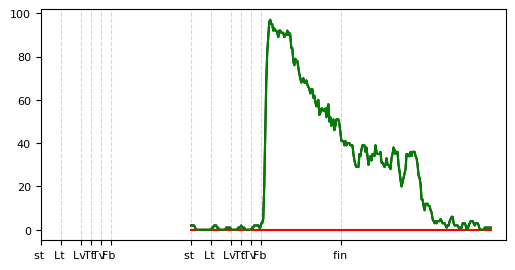

MCC - max signif: 78.71 at time 3.95s
dLPFC - max signif: 53.47 at time 4.65s
vLPFC - max signif: 100.00 at time 3.85s


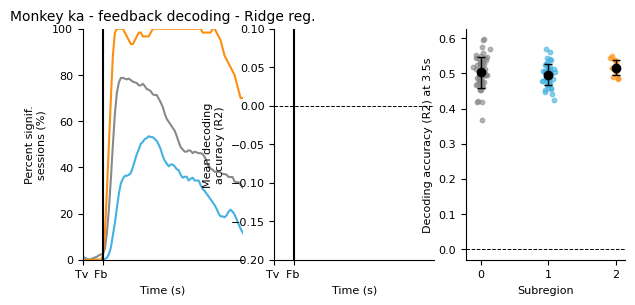

MCC - max signif: 87.55 at time 4.80s
dLPFC - max signif: 63.11 at time 4.45s
vLPFC - max signif: 100.00 at time 4.40s


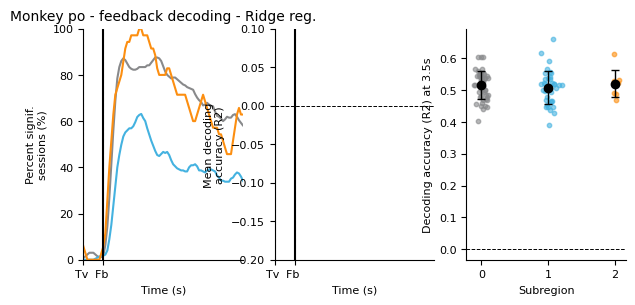

Masked negative scores: 0 out of 69000 total scores.


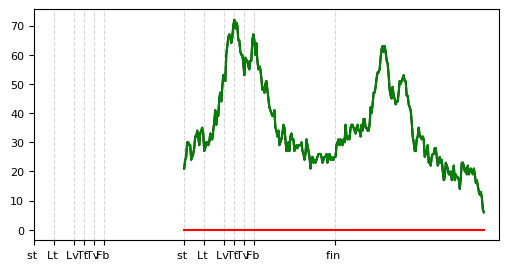

MCC - max signif: 61.61 at time 2.65s
dLPFC - max signif: 73.06 at time 2.30s
vLPFC - max signif: 100.00 at time 2.90s


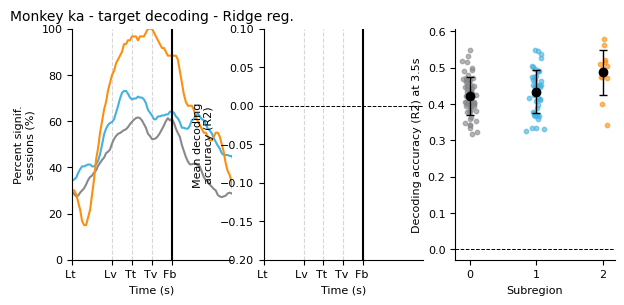

MCC - max signif: 61.89 at time 2.55s
dLPFC - max signif: 63.56 at time 2.40s
vLPFC - max signif: 71.43 at time 2.55s


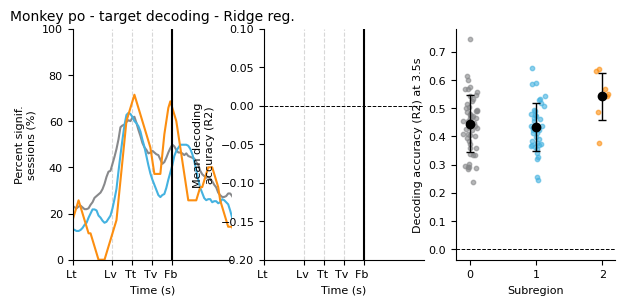

Masked negative scores: 48199 out of 65400 total scores.


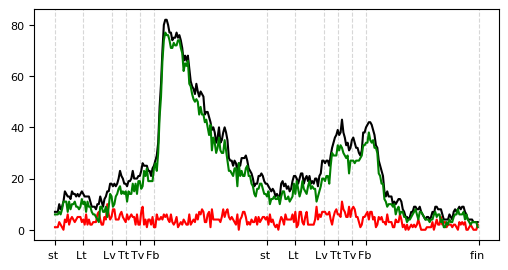

MCC - max signif: 69.83 at time -3.55s
dLPFC - max signif: 26.38 at time -2.60s
vLPFC - max signif: 96.36 at time -2.25s


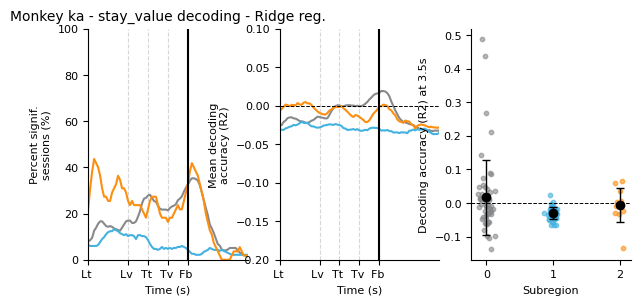

MCC - max signif: 68.40 at time -3.60s
dLPFC - max signif: 31.90 at time -3.00s
vLPFC - max signif: 71.43 at time -3.65s


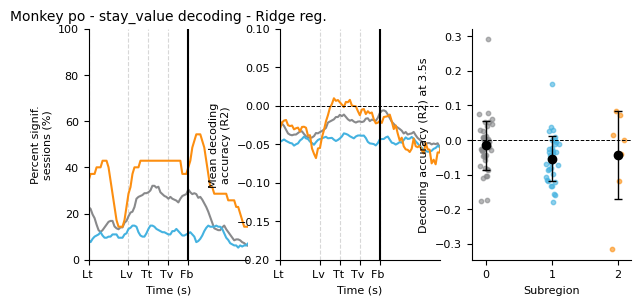

In [7]:
# for each monkey and each target variable (fb, value, target), we plot the 3 areas

plim = .05
n_extra_trials = (0, 1)
N_consecutives = 4

paper_format=False

configs = {
    'feedback': {
        'target': 'feedback',
        'folder': 'fb_target',
        't_window': [3, 7],
    },
    'target': {
        'target': 'target',
        'folder': 'fb_target',
        't_window': [1, 5],
    },
    'stay_value': {
        'target': 'stay_value',
        'folder': 'stay_value',
        't_window': [1, 5],
    }
}

for config_name, config in configs.items():
    target = config['target']
    folder = config['folder']
    t_window = config['t_window']

    # load results

    res = load_decoding_res_new(folder=folder)
    res = add_subareas(res)  # add subareas to the results 
    res = res.sel(target=target)  # select target of interest, e.g. feedback or value

    # if 'group' in dims and its nan, remove it. if not nan, raise error
    if 'group_target' in res.dims:
        if res.group_target == 'None':
            res = res.mean('group_target')
        else:
            raise ValueError("group_target was used so the plotting method cant handle this.")
        
    # mask significants
    res_target_signifs = mask_N_consecutives(res.pvals <= plim, N=N_consecutives)  # mask N consecutive non-significant bins
    res['if_significant'] = res_target_signifs  # add as new dataarray to the results
    res = mask_negative_scores(res)  # mask negative scores, only for ka monkey

    for monkey in np.unique(res.monkey.values):
        res_temp = res.sel(session=res.monkey == monkey)
        title = f'Monkey {monkey} - {target} decoding - Ridge reg.'
        fig, axs = plot_simple_decoding(res_temp, t_window=t_window, mark_event='Fb', n_extra_trials=n_extra_trials, paper_format=paper_format, title=title, ylim=(0, 100))

        # save the figure
        floc = os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'time_resolved_decoders', f'{monkey}_{target}_decoding.svg')
        #plt.savefig(floc, bbox_inches='tight', dpi=300, transparent=True)
        plt.show()
        plt.close()


    "conditions": [  # TODO
        'stay_value', 
        'Q_1_inf', 'Q_1_stand', 'Q_2_inf', 'Q_2_stand', 'Q_3_inf', 'Q_3_stand', 
        'Q_chosen_inf', 'Q_chosen_stand'
    ],

Masked negative scores: 24784 out of 34200 total scores.


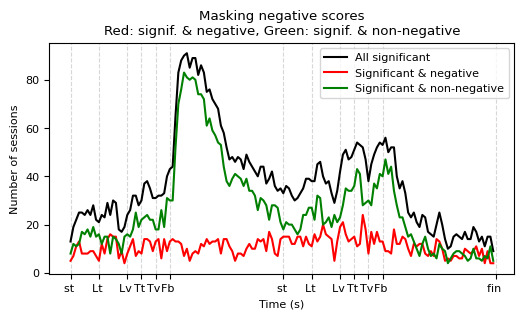

MCC - max signif: 70.97 at time -3.30s
dLPFC - max signif: 29.39 at time -2.70s
vLPFC - max signif: 96.67 at time -1.90s


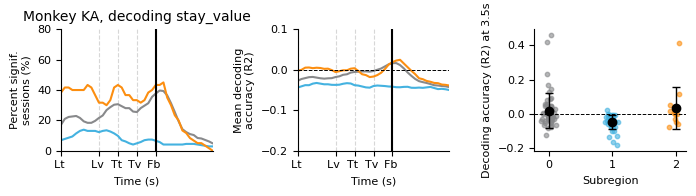

MCC - max signif: 71.15 at time -3.30s
dLPFC - max signif: 32.73 at time -3.30s
vLPFC - max signif: 62.86 at time -3.70s


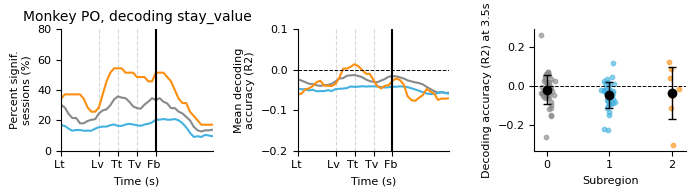

Masked negative scores: 26159 out of 34200 total scores.


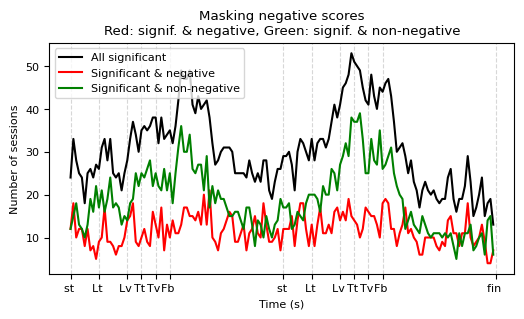

MCC - max signif: 34.52 at time 2.60s
dLPFC - max signif: 40.00 at time 2.40s
vLPFC - max signif: 55.00 at time 2.20s


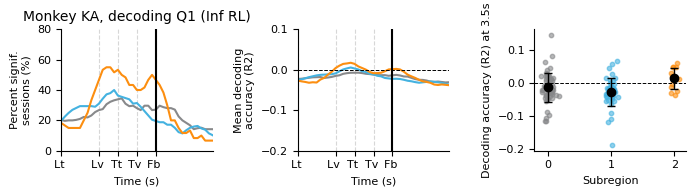

MCC - max signif: 29.62 at time 2.60s
dLPFC - max signif: 25.00 at time 2.30s
vLPFC - max signif: 37.14 at time 3.20s


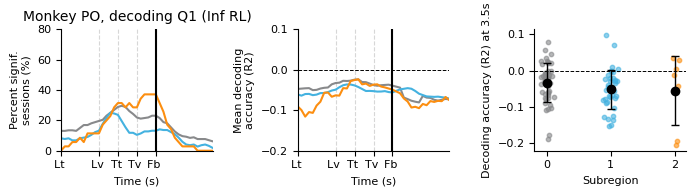

Masked negative scores: 19493 out of 34200 total scores.


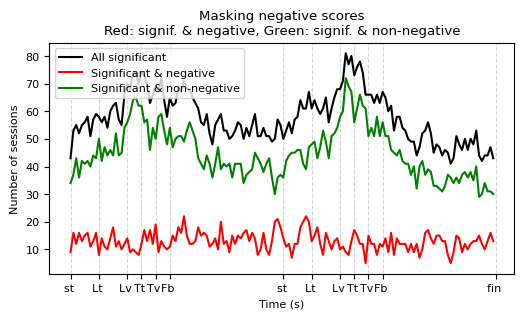

MCC - max signif: 57.74 at time 2.60s
dLPFC - max signif: 52.24 at time -5.10s
vLPFC - max signif: 71.67 at time 2.30s


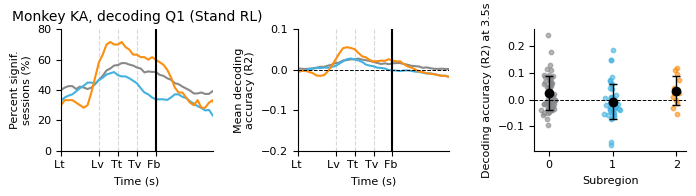

MCC - max signif: 62.31 at time 2.20s
dLPFC - max signif: 43.64 at time 2.40s
vLPFC - max signif: 65.71 at time -3.90s


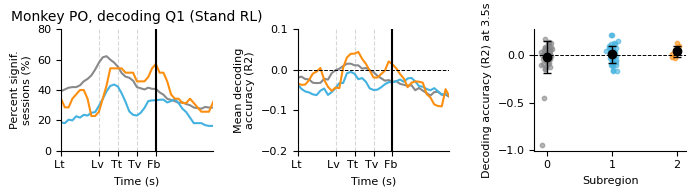

Masked negative scores: 26328 out of 34200 total scores.


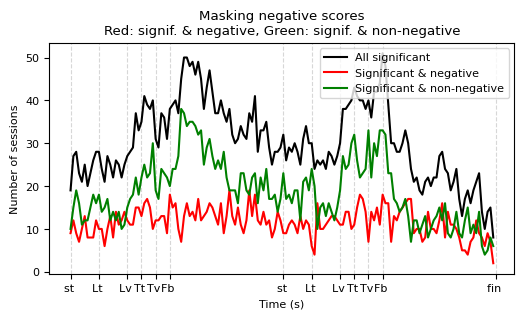

MCC - max signif: 27.10 at time 3.40s
dLPFC - max signif: 29.39 at time 2.60s
vLPFC - max signif: 53.33 at time 2.90s


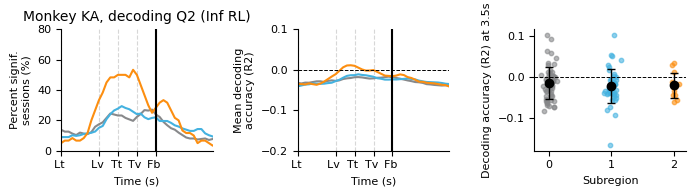

MCC - max signif: 44.62 at time -3.30s
dLPFC - max signif: 19.09 at time 2.30s
vLPFC - max signif: 57.14 at time -2.20s


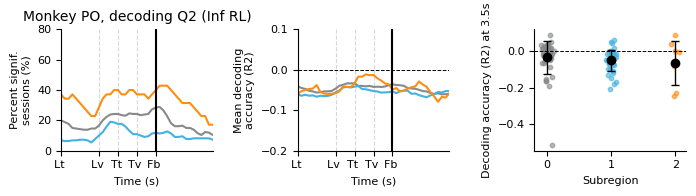

Masked negative scores: 20188 out of 34200 total scores.


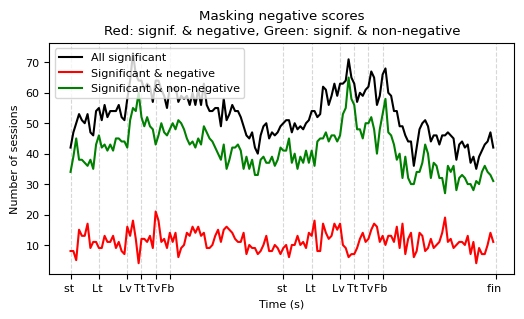

MCC - max signif: 46.77 at time 3.00s
dLPFC - max signif: 48.16 at time -4.80s
vLPFC - max signif: 66.67 at time -5.10s


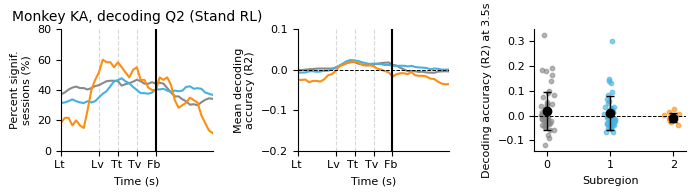

MCC - max signif: 55.38 at time 2.30s
dLPFC - max signif: 38.18 at time 2.40s
vLPFC - max signif: 54.29 at time 6.40s


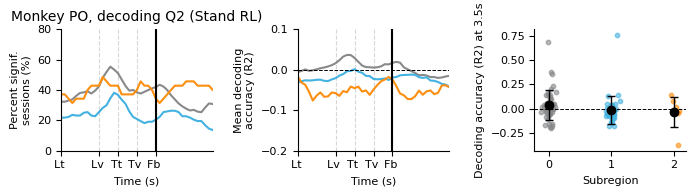

Masked negative scores: 26473 out of 34200 total scores.


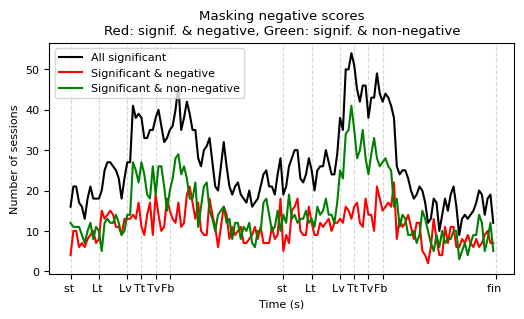

MCC - max signif: 28.39 at time 3.00s
dLPFC - max signif: 37.55 at time 2.40s
vLPFC - max signif: 71.67 at time 2.80s


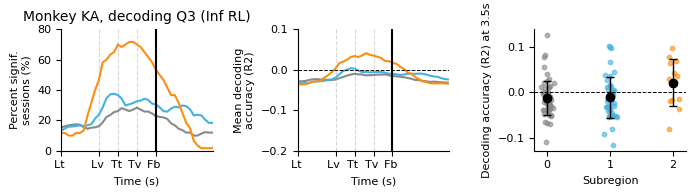

MCC - max signif: 36.54 at time 2.30s
dLPFC - max signif: 30.45 at time 2.50s
vLPFC - max signif: 60.00 at time 3.40s


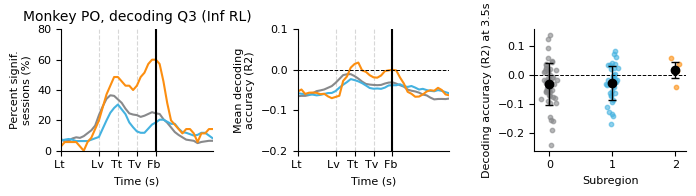

Masked negative scores: 19383 out of 34200 total scores.


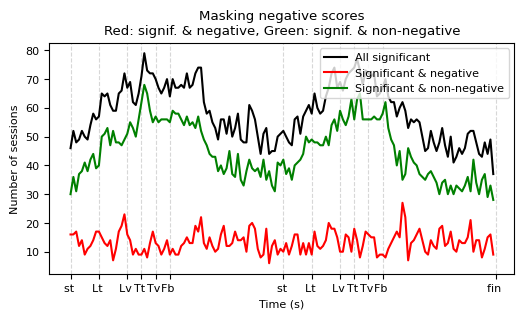

MCC - max signif: 56.77 at time 3.40s
dLPFC - max signif: 52.24 at time -5.10s
vLPFC - max signif: 91.67 at time 2.40s


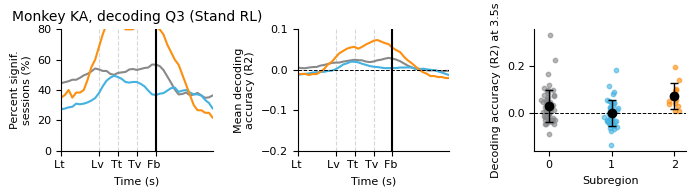

MCC - max signif: 56.54 at time -5.00s
dLPFC - max signif: 48.64 at time -5.00s
vLPFC - max signif: 74.29 at time 2.50s


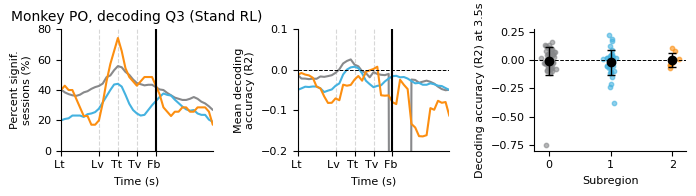

Masked negative scores: 29014 out of 34200 total scores.


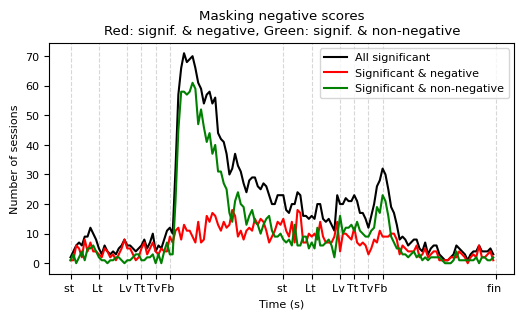

MCC - max signif: 58.39 at time -3.40s
dLPFC - max signif: 18.37 at time -2.70s
vLPFC - max signif: 85.00 at time -2.30s


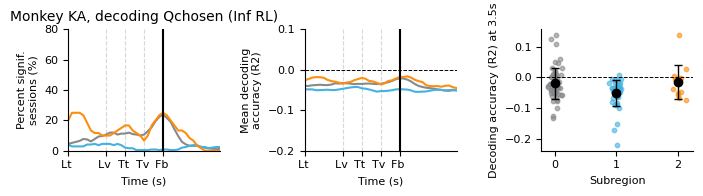

MCC - max signif: 43.08 at time -3.30s
dLPFC - max signif: 21.36 at time -3.00s
vLPFC - max signif: 40.00 at time -2.20s


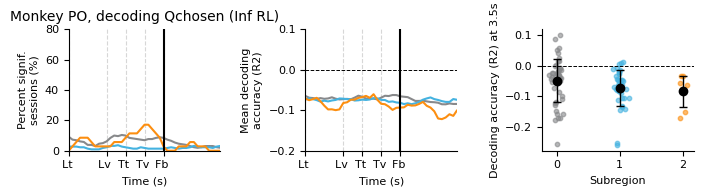

Masked negative scores: 25620 out of 34200 total scores.


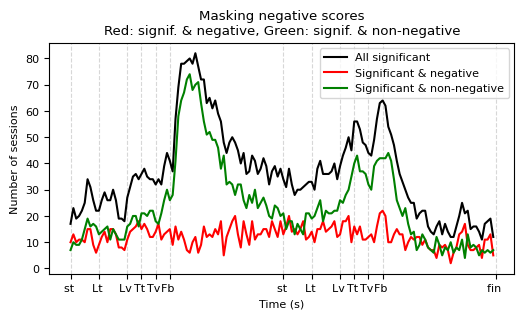

MCC - max signif: 61.94 at time -3.30s
dLPFC - max signif: 16.73 at time -2.70s
vLPFC - max signif: 80.00 at time -2.10s


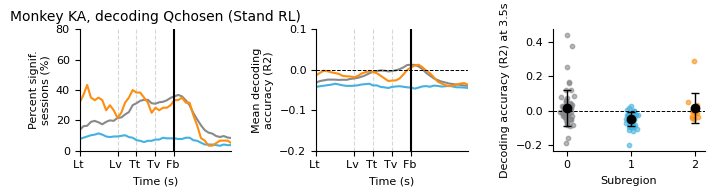

MCC - max signif: 63.08 at time -3.20s
dLPFC - max signif: 27.27 at time -2.80s
vLPFC - max signif: 54.29 at time -3.50s


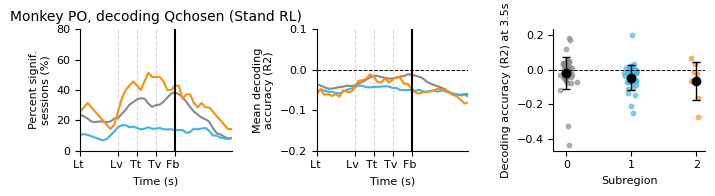

In [46]:
# for each monkey and each target variable (fb, value, target), we plot the 3 areas

plim = .05
n_extra_trials = (0, 1)
N_consecutives = 2

paper_format=True

def target_tits(target):
    """
    Converts from computer naming to printable names as
    
    Q_1_inf -> Q1 (Inferential RL)
    Q_1_stand -> Q1 (Standard RL)
    """
    if target.startswith('Q'):
        return f'Q{target.split("_")[1]} ({target.split("_")[2].capitalize()} RL)'
    return target

configs = {
    'stay_value': {
        'target': 'stay_value',
        'folder': 'alternative_model_values',
        't_window': [1, 5],
    },
    'Q_1_inf': {
        'target': 'Q_1_inf',
        'folder': 'alternative_model_values',
        't_window': [1, 5],
    },
    'Q_1_stand': {
        'target': 'Q_1_stand',
        'folder': 'alternative_model_values',
        't_window': [1, 5],
    },
    'Q_2_inf': {
        'target': 'Q_2_inf',
        'folder': 'alternative_model_values',
        't_window': [1, 5],
    },
    'Q_2_stand': {
        'target': 'Q_2_stand',
        'folder': 'alternative_model_values',
        't_window': [1, 5],
    },
    'Q_3_inf': {
        'target': 'Q_3_inf',
        'folder': 'alternative_model_values',
        't_window': [1, 5],
    },
    'Q_3_stand': {
        'target': 'Q_3_stand',
        'folder': 'alternative_model_values',
        't_window': [1, 5],
    },
    'Q_chosen_inf': {
        'target': 'Q_chosen_inf',
        'folder': 'alternative_model_values',
        't_window': [1, 5],
    },
    'Q_chosen_stand': {
        'target': 'Q_chosen_stand',
        'folder': 'alternative_model_values',
        't_window': [1, 5],
    }
}

for config_name, config in configs.items():
    target = config['target']
    folder = config['folder']
    t_window = config['t_window']

    # load results

    res = load_decoding_res_new(folder=folder)
    res = add_subareas(res)  # add subareas to the results 
    res = res.sel(target=target)  # select target of interest, e.g. feedback or value

    # if 'group' in dims and its nan, remove it. if not nan, raise error
    if 'group_target' in res.dims:
        if res.group_target == 'None':
            res = res.mean('group_target')
        else:
            raise ValueError("group_target was used so the plotting method cant handle this.")
        
    # mask significants
    res_target_signifs = mask_N_consecutives(res.pvals <= plim, N=N_consecutives)  # mask N consecutive non-significant bins
    res['if_significant'] = res_target_signifs  # add as new dataarray to the results
    res = mask_negative_scores(res, plot_res=True)  # mask negative scores, only for ka monkey

    for monkey in np.unique(res.monkey.values):
        res_temp = res.sel(session=res.monkey == monkey)
        title = f'Monkey {monkey.upper()}, decoding {target_tits(target)}'
        fig, axs = plot_simple_decoding(res_temp, t_window=t_window, mark_event='Fb', n_extra_trials=n_extra_trials, paper_format=paper_format, title=title, ylim=(0, 80))

        # save the figure
        floc = os.path.join(PATH, 'notebooks', 'population_decoding', 'figs', 'time_resolved_decoders', 'supplementary', f'{monkey}_{target}_decoding.svg')
        plt.savefig(floc, bbox_inches='tight', dpi=300, transparent=True)
        plt.show()
        plt.close()


In [39]:
'aa'.upper()

'AA'